In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [7]:
# Read in the anndata object 
import anndata as ad
import anndata as ad
from pathlib import Path
import numpy as np
import sys 

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *

splice_adata = ad.read_h5ad("/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-06-11/2025-06-14/param_id_0/data/splice_adata_PHI_psi_var_obs.h5ad")
param_id = 0

# Set model training date and base directories
MODEL_TRAIN_DATE = "2025-06-11"
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION"

# Construct all paths using f-strings
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
ATSE_ANNDATA_PATH = (
    f"{BASE_DIR}/MODEL_INPUT/062025/"
    "HUMAN_SPLICING_FOUNDATION_Anndata_ATSE_counts_53449_junctions_30_waypoints_20250612_110451.h5ad"
)
GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_both_scvi_models_2025-06-06.h5ad"
GE_ANNDATA_NMF_PATH = f"{BASE_DIR}/NMF/ge_adata_with_NMF_model_50_1024_2025-06-06.h5ad"
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"
RESULTS_BASE_DIR = (
    f"/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/"
    f"model_train/HUMAN_FOUNDATION/results/{MODEL_TRAIN_DATE}"
)
ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/stella_gtf/TMS_atse_file_unanno_also_2025-05-11_06-23-05.txt.gz"
)
final_cells = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/062025/filtered_cell_ids.txt"
with open(final_cells, "r") as f:
    final_cells = f.read().splitlines()

# Load splicing data
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
ge_adata_nmf = ad.read_h5ad(GE_ANNDATA_NMF_PATH)
# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]
    ge_adata_nmf.obs["cell_id"] = ge_adata_nmf.obs["cell_id_clean"]

# Only subset by final_cells if in mouse so check if "MOUSE_" is in ATSE_ANNDATA_PATH
if "MOUSE_" in ATSE_ANNDATA_PATH:
    print("   :gear: Subsetting to final cells (outlier removal)...")
    ge_adata = ge_adata[ge_adata.obs["cell_id"].isin(final_cells)].copy()
    ge_adata_nmf = ge_adata_nmf[ge_adata_nmf.obs["cell_id"].isin(final_cells)].copy()

assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
    
# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
if "mouse.id" in splice_adata.obs.columns:
    print(f"Renaming mouse.id to donor_id in splice_adata.obs")
    splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)
    # Update gene annotations
    ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
    ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
    rbps = rbps["mouse_gene_name"]
    print(ge_adata.var["RBP_gene"])
    print(ge_adata.var["Aging_gene"])

else:
    splice_adata.var = add_gene_symbols_to_var(splice_adata.var)
    splice_adata.var["RBP_gene"] = splice_adata.var["gene_name"].isin(rbps["gene_name"]) # when running with Human data... 
    splice_adata.var["Aging_gene"] = splice_adata.var["gene_name"].isin(aging_genes_human)
        
    ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["gene_name"])
    ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_human)
    aging_genes = aging_genes_human
    rbps = rbps["gene_name"]

assert np.all(ge_adata.obs_names == ge_adata_nmf.obs_names), "Cell IDs in ge_adata and ge_adata_nmf do not match or are not in the same order."
assert np.all(ge_adata.var_names == ge_adata_nmf.var_names), "Gene names in ge_adata and ge_adata_nmf do not match or are not in the same order."
ge_adata.obsm["X_nmf_standard_mb"] = ge_adata_nmf.obsm["X_nmf_standard_mb"]
ge_adata.varm["nmf_standard_mb_components"] = ge_adata_nmf.varm["nmf_standard_mb_components"]

# Check if predicted_log_norm_tms not in ge_adata.layers then ge_layer_name="log_norm"
if "predicted_log_norm_tms" not in ge_adata.layers:
    ge_layer_name = "log_norm"
else:
    ge_layer_name = "predicted_log_norm_tms"

Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Loaded 356 RNA binding proteins
Querying MyGeneInfo to map Ensembl gene IDs to gene symbols...


8 input query terms found no hit:	['chr11:113273000', 'chr11:65499000', 'ENSG00000291258', 'chr17:35568000', 'ENSG00000264920', 'ENSG0


Mapped 53361 gene IDs to gene symbols.


In [15]:
splice_adata=ad.read_h5ad(ATSE_ANNDATA_PATH)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [17]:
import scipy.sparse as sp

# Ensure correct matrix
cell_by_junction = splice_adata.layers["cell_by_junction_matrix"]
if not sp.issparse(cell_by_junction):
    cell_by_junction = sp.csr_matrix(cell_by_junction)

# Compute per-cell read counts
splice_adata.obs["reads_per_cell"] = np.ravel(cell_by_junction.sum(axis=1))

# Compute per-cell non-zero junction count
splice_adata.obs["junctions_detected_per_cell"] = np.ravel((cell_by_junction > 0).sum(axis=1))

# Compute per-junction read counts
splice_adata.var["reads_per_junction"] = np.ravel(cell_by_junction.sum(axis=0))

# ---- Summary Statistics ----
print("Reads per cell:\n", splice_adata.obs["reads_per_cell"].describe())
print("\nJunctions with reads > 0 per cell:\n", splice_adata.obs["junctions_detected_per_cell"].describe())
print("\nReads per junction:\n", splice_adata.var["reads_per_junction"].describe())


Reads per cell:
 count    8.851800e+04
mean     7.853062e+04
std      1.409936e+05
min      0.000000e+00
25%      1.820000e+04
50%      3.439350e+04
75%      6.600800e+04
max      3.621447e+06
Name: reads_per_cell, dtype: float64

Junctions with reads > 0 per cell:
 count    88518.000000
mean      1732.301351
std       1427.174086
min          0.000000
25%        569.000000
50%       1386.000000
75%       2601.000000
max      14109.000000
Name: junctions_detected_per_cell, dtype: float64

Reads per junction:
 count    5.344900e+04
mean     1.300562e+05
std      8.198814e+05
min      1.000000e+01
25%      3.282000e+03
50%      2.238600e+04
75%      8.966200e+04
max      8.868554e+07
Name: reads_per_junction, dtype: float64


In [24]:
splice_adata.obs[splice_adata.obs["junctions_detected_per_cell"] == 5].shapes

(102, 14)

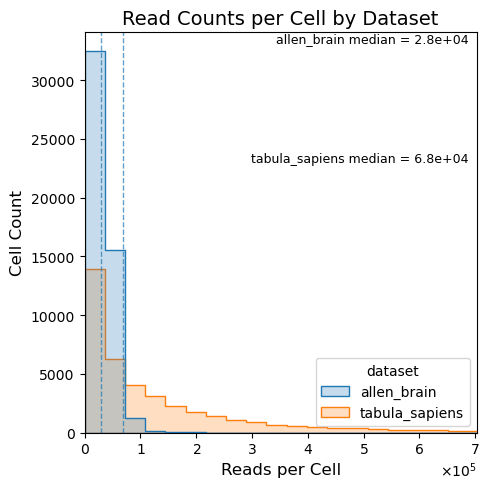

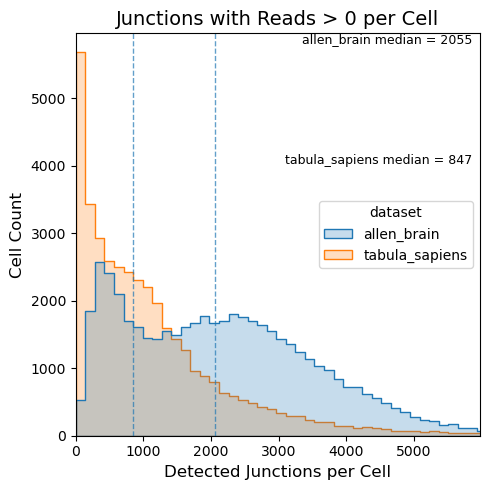

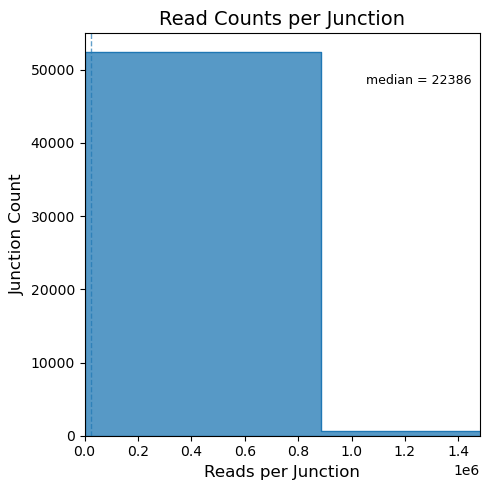

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Plot 1: Reads per Cell by Dataset (with scientific notation) ===
plt.figure(figsize=(5, 5))
sns.histplot(data=splice_adata.obs, x="reads_per_cell", hue="dataset", bins=100,
             multiple="layer", element="step")
plt.title("Read Counts per Cell by Dataset", fontsize=14)
plt.xlabel("Reads per Cell", fontsize=12)
plt.ylabel("Cell Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, np.percentile(splice_adata.obs["reads_per_cell"], 99))

# Use scientific notation on x-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# Add median lines + labels
ylim = plt.ylim()
line_spacing = (ylim[1] * 0.9) / (len(splice_adata.obs["dataset"].unique()) + 1)
for i, ds in enumerate(sorted(splice_adata.obs["dataset"].unique())):
    median_val = splice_adata.obs.loc[splice_adata.obs["dataset"] == ds, "reads_per_cell"].median()
    plt.axvline(median_val, linestyle="--", linewidth=1, alpha=0.7)
    plt.text(plt.xlim()[1] * 0.98, ylim[1] - i * line_spacing,
             f"{ds} median = {int(median_val):.1e}",
             ha="right", va="top", fontsize=9)

plt.tight_layout()
plt.savefig("reads_per_cell_by_dataset.pdf")

# === Plot 2: Junctions Detected per Cell ===
plt.figure(figsize=(5, 5))
sns.histplot(data=splice_adata.obs, x="junctions_detected_per_cell", hue="dataset", bins=100,
             multiple="layer", element="step")
plt.title("Junctions with Reads > 0 per Cell", fontsize=14)
plt.xlabel("Detected Junctions per Cell", fontsize=12)
plt.ylabel("Cell Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, np.percentile(splice_adata.obs["junctions_detected_per_cell"], 99))

ylim = plt.ylim()
line_spacing = (ylim[1] * 0.9) / (len(splice_adata.obs["dataset"].unique()) + 1)
for i, ds in enumerate(sorted(splice_adata.obs["dataset"].unique())):
    median_val = splice_adata.obs.loc[splice_adata.obs["dataset"] == ds, "junctions_detected_per_cell"].median()
    plt.axvline(median_val, linestyle="--", linewidth=1, alpha=0.7)
    plt.text(plt.xlim()[1] * 0.98, ylim[1] - i * line_spacing,
             f"{ds} median = {int(median_val)}",
             ha="right", va="top", fontsize=9)

plt.tight_layout()
plt.savefig("junctions_per_cell_by_dataset.pdf")

# === Plot 3: Reads per Junction ===
plt.figure(figsize=(5, 5))
sns.histplot(splice_adata.var["reads_per_junction"], bins=100, element="step")
plt.title("Read Counts per Junction", fontsize=14)
plt.xlabel("Reads per Junction", fontsize=12)
plt.ylabel("Junction Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, np.percentile(splice_adata.var["reads_per_junction"], 99))

median_val = splice_adata.var["reads_per_junction"].median()
plt.axvline(median_val, linestyle="--", linewidth=1, alpha=0.7)
plt.text(plt.xlim()[1] * 0.98, plt.ylim()[1]*0.9,
         f"median = {int(median_val)}", ha="right", va="top", fontsize=9)

plt.tight_layout()
plt.savefig("reads_per_junction.pdf")


In [ ]:
groupby="broad_cell_type"
# Extract PHI matrix
X_PHI = splice_adata.obsm["X_PHI"]
n_factors = X_PHI.shape[1]
factor_cols = [f"factor_{i}" for i in range(n_factors)]

# within each cell type, get factor delta between young and old, median (old) - median (young) 
df_all = pd.DataFrame(X_PHI, columns=factor_cols)
df_all[groupby] = splice_adata.obs[groupby].values
df_all["age_group"] = splice_adata.obs["age_group"].values
# Group by groupby + age_group
median_by_group_and_age = df_all.groupby([groupby, "age_group"], observed=True)[factor_cols].median()
# Pivot into two matrices: one for young, one for old
median_young = median_by_group_and_age.xs("young", level="age_group")
median_old = median_by_group_and_age.xs("old", level="age_group")
# Align index (cell types) and subtract
delta_median = median_old - median_young    
delta_median = delta_median.fillna(0)

# Save delta matrix
# Reorder delta_median based on median_expression clustermap (g2)
# Plot delta clustermap (same row/col order as mean_expression)
g4 = sns.clustermap(
    delta_median,
    cmap="BrBG",
    center=0,
    figsize=(5, 4),
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'Δ(Old - Young)'},
    linewidths=0.2,
    linecolor='gray',
    row_cluster=True,
    col_cluster=True
)
# Use same tick label formatting
plt.setp(g4.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=6)
plt.setp(g4.ax_heatmap.get_yticklabels(), rotation=0, fontsize=5)
g4.ax_cbar.set_ylabel("Δ(Old - Young)", fontsize=8)  # Set your desired size
g4.ax_cbar.tick_params(labelsize=6)
# Change xlab to "Broad Cell Type"
plt.savefig("delta_median_old_minus_young_by_broad_cell_type.pdf", format="pdf")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Extract matrix
X_PHI = splice_adata.obsm["X_PHI"]
n_factors = X_PHI.shape[1]
factor_cols = [f"factor_{i}" for i in range(n_factors)]

# Build DataFrame
df_all = pd.DataFrame(X_PHI, columns=factor_cols)
df_all[groupby] = splice_adata.obs[groupby].values

# Set zero values to NaN to ignore them in median calculation
df_all_nonzero = df_all.copy()
df_all_nonzero[factor_cols] = df_all_nonzero[factor_cols].mask(df_all_nonzero[factor_cols] == 0)

# Compute median nonzero activity for each cell type and factor
median_nonzero = df_all_nonzero.groupby(groupby, observed=True)[factor_cols].median()
median_nonzero = median_nonzero.fillna(0)

# Use same row/col order as g4
row_order = [median_nonzero.index[i] for i in g4.dendrogram_row.reordered_ind]
col_order = [median_nonzero.columns[i] for i in g4.dendrogram_col.reordered_ind]
median_nonzero = median_nonzero.loc[row_order, col_order]

# Plot
g5 = sns.clustermap(
    median_nonzero,
    cmap="PRGn",
    center=0,
    figsize=(5, 4),
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'Median Factor Activity (nonzero)'},
    row_cluster=False,
    col_cluster=False,
    linewidths=0.2,
    linecolor='gray'
)

plt.setp(g5.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=6)
plt.setp(g5.ax_heatmap.get_yticklabels(), rotation=0, fontsize=5)
g5.ax_cbar.set_ylabel("Median Nonzero \nFactor Activity", fontsize=6)  # Set your desired size
g5.ax_cbar.tick_params(labelsize=6)


plt.savefig("median_nonzero_factor_activity_by_broad_cell_type.pdf", format="pdf")


In [6]:
# read in factor labels 
factor_labels = pd.read_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-06-11/2025-06-14/param_id_0/data/factor_label_df.csv")

In [7]:
def relabel_covariate(row):
    covs = row['top_covariates']
    has_celltype = 'C(cell_type)' in covs
    has_age = 'age' in covs
    has_tissue = 'C(tissue)' in covs
    has_sex = 'C(sex)' in covs
    has_interaction = 'C(cell_type):age' in covs

    labels = []

    if has_interaction:
        labels.append('cell_type:age')
    if has_celltype:
        labels.append('cell_type')
    if has_age:
        labels.append('age')
    if has_tissue:
        labels.append('tissue')
    if has_sex:
        labels.append('sex')

    return ' + '.join(labels) if labels else 'other'

factor_labels['combined_label'] = factor_labels.apply(relabel_covariate, axis=1)

In [ ]:
pi="/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-06-11/2025-06-14/param_id_0/data/PI_values.npy"
pi = np.load(pi)
pi

In [ ]:
factor_labels

In [ ]:
# Create DataFrame for pi values
pi_df = pd.DataFrame({
    "factor_id": [f"factor_{i}" for i in range(len(pi))],
    "PI": pi
})

# Merge with factor_labels by factor_id
df = factor_labels.merge(pi_df, on="factor_id")

# Sort by R²
df = df.sort_values("r2", ascending=False).copy()

# Add rank and formatted label
df["rank"] = range(1, len(df) + 1)

# Plot
plt.figure(figsize=(4, 6))
ax = sns.barplot(data=df, y="factor_id", x="r2", hue="combined_label", dodge=False)

# Add dashed red line at R^2 = 0.5
plt.axvline(x=0.5, color='grey', linestyle='--', linewidth=1)

# Annotate each bar with PI value
for i, (r2_val, pi_val) in enumerate(zip(df["r2"], df["PI"])):
    ax.text(
        x=r2_val + 0.01,
        y=i,
        s=f"PI={pi_val:.2f}",
        va='center',
        ha='left',
        fontsize=8
    )

plt.xlabel("R² (Explained Variance)")
plt.ylabel("Factor")
plt.tight_layout()

# Make legend smaller
#plt.legend(title="Top Covariate", bbox_to_anchor=(1.05, 0.8), loc='upper left', fontsize=8)
plt.savefig("top_covariates_explaining_each_factor.pdf", format="pdf")

plt.show()


In [11]:
# Create column names
factor_cols = [f"Factor_{i}" for i in range(splice_adata.obsm["X_PHI"].shape[1])]

# Convert to DataFrame
phi_df = pd.DataFrame(splice_adata.obsm["X_PHI"], columns=factor_cols, index=splice_adata.obs_names)

# Merge into obs
splice_adata.obs = splice_adata.obs.join(phi_df)


In [12]:
# Use the updated obs DataFrame
df = splice_adata.obs
import matplotlib.pyplot as plt
import seaborn as sns

def plot_factor_violin(
    adata,
    factor_list,
    groupby="broad_cell_type",
    include_groups=None,
    figsize=(4, 4),
    save_prefix=None
):
    """
    Plot violinplots of factor activity grouped by a metadata category.

    Args:
        adata: AnnData object with factor columns in `.obs` (e.g., 'Factor_0', ...)
        factor_list: list of factor names as strings (e.g., ['Factor_0', 'Factor_3'])
        groupby: obs column to group by (e.g., 'tissue', 'age_group', etc.)
        include_groups: list of values in `groupby` to include (e.g., ['3m', '24m'])
        figsize: tuple for figure size
        save_prefix: optional prefix to save each figure as a PDF
    """
    df = adata.obs.copy()

    if include_groups is not None:
        df = df[df[groupby].isin(include_groups)]

    for factor in factor_list:
        plt.figure(figsize=figsize)
        sns.violinplot(
            data=df,
            linewidth=1, linecolor="k",
            x=groupby,    palette="Set2",
            inner="quart",
            y=factor, fill=False)
        
        plt.title(f"{factor} Activity by {groupby}")
        plt.xlabel(groupby)
        plt.ylabel("Factor Activity")
        plt.xticks(rotation=45, fontsize=14)
        plt.yticks(fontsize=14)
        plt.tight_layout()

        if save_prefix:
            plt.savefig(f"{save_prefix}_{factor}_by_{groupby}.pdf", format="pdf")
        plt.show()

In [13]:
def plot_factor_violin_sorted(
    adata,
    factor_list,
    groupby="broad_cell_type",
    include_groups=None,
    width=8,       # ← fixed width
    height=4,
    cmap="YlGnBu",
    top_n=10,
    save_prefix=None
):
    """
    Plot violin plots of factor activity grouped by a metadata field,
    showing top_n groups by median activity and collapsing the rest as 'Other'.

    Args:
        adata: AnnData object
        factor_list: list of factor column names in .obs (e.g. ['Factor_1'])
        groupby: obs column to group by (e.g., 'broad_cell_type')
        include_groups: list of groupby values to include (optional)
        width: fixed figure width
        height: fixed figure height
        cmap: matplotlib colormap name (e.g., 'YlGnBu')
        top_n: number of top groups (by median) to display; rest go into "Other"
        save_prefix: if provided, saves plots to PDF
    """
    obs_df = adata.obs.copy()
    if include_groups is not None:
        obs_df = obs_df[obs_df[groupby].isin(include_groups)]

    for factor in factor_list:
        plot_df = obs_df[[groupby, factor]].dropna()

        # Compute medians and get top_n groups
        medians = plot_df.groupby(groupby)[factor].median().sort_values(ascending=False)
        top_groups = medians.head(top_n).index.tolist()

        # Map rest to "Other"
        plot_df[groupby] = plot_df[groupby].apply(lambda x: x if x in top_groups else "Other")

        # Define plot order: top groups + Other
        plot_order = top_groups + ["Other"]

        # Categorical for ordering
        plot_df[groupby] = pd.Categorical(plot_df[groupby], categories=plot_order, ordered=True)

        # Build color palette (add grey for "Other")
        base_palette = sns.color_palette(cmap, len(top_groups))
        color_map = dict(zip(top_groups, base_palette))
        color_map["Other"] = "lightgrey"

        plt.figure(figsize=(width, height))

        sns.violinplot(
            data=plot_df,
            x=groupby,
            y=factor,
            order=plot_order,
            palette=color_map,
            inner="box",
            cut=0
        )

        plt.title(f"{factor} Activity by Top {top_n} {groupby} (+Other)")
        plt.xlabel(groupby)
        plt.ylabel("Factor Activity")
        plt.xticks(rotation=90)
        plt.tight_layout()

        if save_prefix:
            plt.savefig(f"{save_prefix}_{factor}_by_{groupby}_top{top_n}_with_other.pdf", format="pdf")

        plt.show()

In [ ]:
plot_factor_violin(
    adata=splice_adata,
    factor_list=["Factor_27"],
    groupby="age_group",
    include_groups=["young", "old"],
    save_prefix="factor_age_violin"
)

In [ ]:
plot_factor_violin(
    adata=splice_adata,
    factor_list=["Factor_27"],
    groupby="age_numeric",
    save_prefix="factor_age_violin"
)

In [ ]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["Factor_27"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_factor_age_trends(
    df,
    factor,
    groupby="broad_cell_type",
    age_col="age_numeric",
    top_n=7,
    figsize=(4, 4),
    title_prefix=None,
    save_path=None
):
    """
    Plot median factor activity over age, labeled by top N cell types.

    Args:
        df: DataFrame (e.g., `splice_adata.obs`) with factor, groupby, and age columns
        factor: column name of the factor (e.g., "Factor_1")
        groupby: grouping variable, e.g. "broad_cell_type"
        age_col: age variable (numeric), e.g. "age_numeric"
        top_n: number of top groups to plot by median factor activity
        figsize: tuple for figure size
        title_prefix: string to prepend to title (optional)
        save_path: if given, saves the figure to this path
    """
    # Step 1: rank groups by median factor activity
    overall_median = (
        df.groupby(groupby)[factor]
        .median()
        .sort_values(ascending=False)
    )
    top_groups = overall_median.head(top_n).index.tolist()

    # Step 2: subset data
    filtered_df = df[df[groupby].isin(top_groups)]

    # Step 3: summarize median by age within group
    summary = (
        filtered_df.groupby([groupby, age_col])[factor]
        .median()
        .reset_index()
    )

    # Step 4: plot
    plt.figure(figsize=figsize)
    ax = sns.lineplot(
        data=summary,
        x=age_col,
        y=factor,
        hue=groupby,
        marker="o",
        legend=False
    )

    # Step 5: label last point per group
    for group in summary[groupby].unique():
        data_ct = summary[summary[groupby] == group]
        first = data_ct.sort_values(age_col).iloc[0]
        ax.text(
            x=first[age_col] - 0.2,
            y=first[factor],
            s=group,
            fontsize=7,
            va='center'
        )

    # Final formatting
    title = f"{factor} Median Activity by Age"
    if title_prefix:
        title = f"{title_prefix}: {title}"
    plt.title(title)
    plt.xlabel("Age (months)")
    plt.ylabel("Median Factor Activity")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format="pdf")

    plt.show()


In [ ]:
plot_factor_age_trends(
    df=splice_adata.obs,
    factor="Factor_2",
    top_n=5,
    title_prefix="Top Aging Cell Types",
    save_path="Factor_1_age_trend_top5.pdf"
)


In [ ]:
common_cell_types

In [ ]:
# Get cell type counts by dataset to get common cell types
# Get cell type counts by dataset to get common cell types
cell_type_counts = splice_adata.obs.groupby(['broad_cell_type', 'dataset']).size().unstack()
common_cell_types = cell_type_counts[(cell_type_counts["allen_brain"] > 0) & (cell_type_counts["tabula_sapiens"] > 0)]
common_cell_type_names = common_cell_types.index.tolist()
common_cell_type_names = ["Microglia"]
common_cell_type_names

In [ ]:
adata_common = splice_adata[splice_adata.obs["broad_cell_type"].isin(common_cell_type_names)].copy()
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].cat.remove_unused_categories()

# Extract factor values
num_factors = adata_common.obsm["X_PHI"].shape[1]
factor_cols = [f"Factor_{i}" for i in range(num_factors)]
df = adata_common.obs[["broad_cell_type", "dataset"]].copy()

for i, col in enumerate(factor_cols):
    df[col] = adata_common.obsm["X_PHI"][:, i]

median_profiles = (
    df.groupby(["broad_cell_type", "dataset"])[factor_cols]
    .median()
    .reset_index()
)

# Create composite label
median_profiles["label"] = (
    median_profiles["broad_cell_type"].astype(str)
    + " (" +
    median_profiles["dataset"].astype(str)
    + ")"
)

median_profiles = median_profiles.set_index("label")[factor_cols]

# Cluster heatmap
g = sns.clustermap(
    median_profiles,
    method="average",
    metric="euclidean",
    cmap="PRGn",
    center=0,
    linewidths=0.2,
    linecolor='gray',
    figsize=(6, 4)
)

g.savefig("clustering_common_celltype_dataset_factors.pdf")

plt.show()


In [ ]:
factor_labels

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_factor_violin_by_age(
    df,
    factor,
    cell_types,
    age_col="age_numeric",
    groupby="broad_cell_type",
    figsize=(6, 4),
    title_prefix=None,
    save_path=None
):
    """
    Plot violin plots of factor activity across age (categorical) for selected cell types.
    Annotates median factor values above each violin.

    Args:
        df: DataFrame with factor and metadata
        factor: name of the factor column (e.g., "Factor_1")
        cell_types: list of cell types to include (values in groupby column)
        age_col: numeric column representing age (converted to categorical)
        groupby: metadata column representing cell type (e.g., "broad_cell_type")
        figsize: figure size tuple
        title_prefix: optional title prefix
        save_path: optional path to save figure
    """
    df_sub = df[df[groupby].isin(cell_types)].copy()

    if pd.api.types.is_categorical_dtype(df_sub[groupby]):
        df_sub[groupby] = df_sub[groupby].cat.remove_unused_categories()

    sorted_ages = sorted(df_sub[age_col].dropna().unique())
    df_sub[age_col] = pd.Categorical(df_sub[age_col], categories=sorted_ages, ordered=True)

    # Plot
    plt.figure(figsize=figsize)
    ax = sns.violinplot(
        data=df_sub,
        x=age_col,
        y=factor,
        hue=groupby,
        split=False,
        inner="quartile",
        linewidth=1
    )

    # Compute medians for labeling
    median_df = df_sub.groupby([groupby, age_col])[factor].median().reset_index()
    print(median_df)

    # Annotate medians
    for i, row in median_df.iterrows():
        subset = df_sub[(df_sub[groupby] == row[groupby]) & (df_sub[age_col] == row[age_col])]
        xpos = sorted_ages.index(row[age_col])
        offset = 0.2 * list(df_sub[groupby].cat.categories).index(row[groupby])  # space between groups
        ax.text(
            x=xpos + offset,
            y=row[factor] + 0.02,
            s=f"{row[factor]:.2f}",
            ha='center',
            va='bottom',
            fontsize=8,
            color='black',
            rotation=0,
            clip_on=True
        )

    # Clean up legend
    handles, labels = ax.get_legend_handles_labels()
    if len(cell_types) > 1:
        ax.legend(handles[:len(cell_types)], labels[:len(cell_types)], title=groupby, bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        ax.legend_.remove()

    # Labels
    title = f"{factor} Activity Across Ages"
    if title_prefix:
        title = f"{title_prefix}: {title}"
    plt.title(title, fontsize=8)
    # adjiust tick font size
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.xlabel("Age (months)", fontsize=11)
    plt.ylabel("Factor Activity", fontsize=11)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format="pdf")

    plt.show()


In [ ]:
plot_factor_violin_by_age(
    df=splice_adata.obs,
    factor="Factor_5",
    cell_types=["BLADDER CELL"],
    title_prefix="Bladder Cell", 
    figsize=(4, 4), 
    save_path="Factor_5_age_violin_bladder_cell.pdf"
)


In [ ]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["Factor_2"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


In [9]:
# load differential splicing results
diff_spl = pd.read_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-06-11/2025-06-14/param_id_0/data/differential_splicing_results.csv")
diff_spl

,factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,RBP_gene,Aging_gene,junction_label,perfect_match_5_prime,perfect_match_3_prime,junction_annotation
0,0,20,-0.273614,0.273614,0.012470,84.0,0.84,0.16,True,0.2,...,1975,0.022312,2.0,1.5,False,False,Other,"s-9021112495203281550:e-5682522846778797042,EN...","s-9021112495203281550:e-5682522846778797042,EN...",Both_SS_annotated
1,0,53,0.276979,0.276979,0.001195,98.0,0.98,0.02,True,0.2,...,6456,0.072934,2.0,1.5,False,False,Other,"ENST00000370151.9,ENST00000370147.5,s-50707388...","ENST00000370151.9,s-5070738839909815654:e65486...",Both_SS_annotated
2,0,73,0.309226,0.309226,0.003025,97.0,0.97,0.03,True,0.2,...,24931,0.281649,2.0,1.5,False,False,Other,"s-8367807194111363331:e4566172033694715275,ENS...","s-8367807194111363331:e4566172033694715275,ENS...",Both_SS_annotated
3,0,79,-0.563623,0.563623,0.013167,98.0,0.98,0.02,True,0.2,...,2244,0.025351,2.0,1.5,False,False,Other,"ENST00000348850.9,s1983140775549581074:e-10798...","ENST00000348850.9,s1983140775549581074:e-10798...",Both_SS_annotated
4,0,81,-0.584702,0.584702,0.007935,100.0,1.00,0.00,True,0.2,...,2273,0.025678,2.0,1.5,False,False,Other,"ENST00000348850.9,s1983140775549581074:e-10798...","ENST00000348850.9,s1983140775549581074:e-10798...",Both_SS_annotated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91991,27,53422,-0.634483,0.634483,0.000114,100.0,1.00,0.00,True,0.2,...,13864,0.156624,2.0,1.5,False,False,Other,"s-3836660072481207772:e-7429908657185784174,EN...","s-3836660072481207772:e-7429908657185784174,EN...",Both_SS_annotated
91992,27,53429,0.470029,0.470029,0.001777,100.0,1.00,0.00,True,0.2,...,3306,0.037348,2.0,1.5,False,False,Other,"s-5816768753928047705:e-6530931705323192890,s-...","s-5816768753928047705:e-6530931705323192890,s-...",Both_SS_annotated
91993,27,53432,-0.478841,0.478841,0.048444,89.0,0.89,0.11,True,0.2,...,4099,0.046307,2.0,1.5,True,False,RBP,"ENST00000336079.8,s-3021202369245031019:e-2282...","ENST00000336079.8,s-3021202369245031019:e-2282...",Both_SS_annotated
91994,27,53440,-0.386181,0.386181,0.012126,93.0,0.93,0.07,True,0.2,...,5423,0.061264,2.0,1.5,False,False,Other,"ENST00000331397.8,ENST00000682913.1,s-42506461...","ENST00000331397.8,ENST00000682913.1,s-42506461...",Both_SS_annotated


In [10]:
diff_spl["factor_idx"].value_counts()

factor_idx
8     12132
21     8846
13     6935
0      6868
2      6236
27     6105
18     6038
6      4607
9      4596
5      4362
10     3235
22     2579
3      2256
19     2026
23     1647
14     1628
1      1338
25     1263
4      1209
24     1137
15     1017
17      994
26      988
12      964
20      948
11      752
16      684
7       606
Name: count, dtype: int64

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

def plot_gene_vs_factor_correlation(
    splice_adata,
    ge_adata,
    gene_name,
    factor_col,
    layer="predicted_log_norm_tms",
    plot_type="scatter",  # 'scatter', 'kde', or 'hist'
    save_path=None,
    show_legend=True,
    groupby=None
):
    """
    Plot correlation between gene expression and splicing factor activity.

    Args:
        splice_adata: AnnData with factor activity in .obs
        ge_adata: AnnData with gene expression in .layers[layer]
        gene_name: str, name of the gene to correlate (e.g., 'Eif4a2')
        factor_col: str, column in .obs of splice_adata with factor activity (e.g., 'Factor_2')
        layer: str, layer name in ge_adata for expression
        plot_type: 'scatter' (default), 'kde' (2D density), or 'hist' (2D heatmap)
        save_path: optional file path to save figure
        show_legend: whether to show group labels if groupby is used
        groupby: optional obs column name for coloring
    """
    # Match cell order
    assert np.all(splice_adata.obs["cell_id"].values == ge_adata.obs["cell_id"].values), "Mismatched cell order."

    # Get gene index
    gene_mask = ge_adata.var["gene_name"] == gene_name
    if not gene_mask.any():
        raise ValueError(f"Gene '{gene_name}' not found in ge_adata.var['gene_name'].")

    gene_idx = np.where(gene_mask)[0][0]
    gene_expr = ge_adata[:, gene_idx].layers[layer]

    # Convert sparse to dense if needed
    if hasattr(gene_expr, "toarray"):
        gene_expr = gene_expr.toarray().ravel()
    else:
        gene_expr = np.ravel(gene_expr)

    # Prepare dataframe
    factor_values = splice_adata.obs[factor_col].values
    df = pd.DataFrame({
        "gene_expr": gene_expr,
        "factor_activity": factor_values
    })
    if groupby and groupby in splice_adata.obs.columns:
        df[groupby] = splice_adata.obs[groupby].values

    # Correlation
    rho, pval = spearmanr(df["gene_expr"], df["factor_activity"], nan_policy="omit")
    corr_label = f"Spearman ρ = {rho:.2f}, p = {pval:.1e}"

    # Plot
    plt.figure(figsize=(5, 4))

    if plot_type == "scatter":
        sns.scatterplot(
            data=df,
            x="gene_expr",
            y="factor_activity",
            hue=groupby if groupby else None,
            s=10,
            alpha=0.7,
            linewidth=0
        )

    elif plot_type == "kde":
        sns.kdeplot(
            data=df,
            x="gene_expr",
            y="factor_activity",
            fill=True,
            cmap="mako",
            levels=100,
            thresh=0.05
        )

    elif plot_type == "hist":
        sns.histplot(
            data=df,
            x="gene_expr",
            y="factor_activity",
            bins=100,
            pthresh=0.05,
            cmap="viridis",
            cbar=True
        )

    else:
        raise ValueError("plot_type must be 'scatter', 'kde', or 'hist'.")

    plt.xlabel(f"{gene_name} expression")
    plt.ylabel(f"{factor_col} activity")
    plt.title(corr_label)

    if groupby and plot_type == "scatter" and not show_legend:
        plt.legend([], [], frameon=False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format="pdf")
    plt.show()


In [ ]:
plot_gene_vs_factor_correlation(
    splice_adata=splice_adata,
    layer="log_norm",
    ge_adata=ge_adata,
    gene_name="MALAT1",
    factor_col="Factor_2",
    plot_type="hist"  # try "scatter", "kde", or "hist"
)


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scanpy as sc

def plot_gene_and_factor_umap_from_phi(
    splice_adata,
    ge_adata,
    gene_name,
    factor_name,
    groupby=None,
    group_level=None,
    layer="predicted_log_norm_tms",
    cmap="viridis",
    figsize=(6, 4),
    umap_n_neighbors=8,
    umap_min_dist=0.3,
    random_state=0
):
    """
    Run UMAP on X_PHI for a subset of cells and plot factor and gene expression.

    Args:
        splice_adata: AnnData with obsm['X_PHI'] and factor activity in .obs
        ge_adata: AnnData with gene expression in .layers[layer]
        gene_name: name of gene to visualize
        factor_name: column in .obs with factor activity
        groupby: obs column for subsetting (e.g. 'broad_cell_type')
        group_level: value in groupby to subset to (e.g. 'MICROGLIA')
        layer: gene expression layer name
        cmap: colormap for both UMAPs
        figsize: tuple, size of the figure
        umap_n_neighbors: neighbors param
        umap_min_dist: UMAP min_dist param
        random_state: random seed for reproducibility
    """
    assert np.all(splice_adata.obs["cell_id"].values == ge_adata.obs["cell_id"].values), "Cell mismatch!"

    # Subset to group if specified
    if groupby and group_level:
        mask = splice_adata.obs[groupby] == group_level
    else:
        mask = np.ones(splice_adata.n_obs, dtype=bool)

    splice_sub = splice_adata[mask].copy()
    ge_sub = ge_adata[mask].copy()

    # Run neighbors + UMAP
    sc.pp.neighbors(splice_sub, use_rep="X_PHI", n_neighbors=umap_n_neighbors)
    sc.tl.umap(splice_sub, min_dist=umap_min_dist, random_state=random_state)

    umap = splice_sub.obsm["X_umap"]

    # Factor activity
    factor_values = splice_sub.obs[factor_name].values

    # Gene expression
    gene_idx = np.where(ge_sub.var["gene_name"] == gene_name)[0]
    if len(gene_idx) != 1:
        raise ValueError(f"Gene '{gene_name}' not found or ambiguous.")
    expr = ge_sub[:, gene_idx[0]].layers[layer]
    if hasattr(expr, "toarray"):
        expr = expr.toarray().ravel()
    else:
        expr = np.ravel(expr)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, values, title in zip(
        axes,
        [expr, factor_values],
        [f"{gene_name} expression", f"{factor_name} activity"]
    ):
        scp = ax.scatter(
            umap[:, 0], umap[:, 1],
            c=values,
            cmap=cmap,
            s=3,
            alpha=0.5
        )
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(scp, ax=ax, fraction=0.046, pad=0.04)

    if groupby and group_level:
        fig.suptitle(f"{group_level} cells", fontsize=12)

    plt.tight_layout()
    plt.show()


In [39]:
import scanpy as sc

# Run neighbors and UMAP on X_PHI embedding
sc.pp.neighbors(splice_adata, use_rep="X_PHI", n_neighbors=8)
sc.tl.umap(splice_adata, random_state=0, min_dist=0.3)

In [40]:
nmf_single = pd.read_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-06-11/2025-06-14/param_id_0/data/single_rbp_factor_correlations_rho.csv")

In [ ]:
nmf_single.sort_values(by="Factor2").iloc[0:20]

In [ ]:
plot_gene_and_factor_umap_from_phi(
    splice_adata=splice_adata,
    ge_adata=ge_adata,
    layer="log_norm",
    gene_name="PSIP1",
    factor_name="Factor_2",
    groupby=None,
    group_level=None
)


In [47]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gene_and_factor_umap_from_phi(
    splice_adata,
    ge_adata,
    gene_name,
    factor_name,
    layer="log_norm",
    groupby=None,
    group_level=None,
    cmap="plasma",
    figsize=(10, 4),
    s=4,
    alpha=0.6
):
    """
    Plot UMAPs of gene expression and factor activity side by side for subset of cells.

    splice_adata must already have UMAP computed on X_PHI stored in obsm["X_umap"].
    """
    # Subset cells
    if groupby and group_level:
        mask = splice_adata.obs[groupby] == group_level
    else:
        mask = np.ones(splice_adata.shape[0], dtype=bool)

    splice_sub = splice_adata[mask].copy()
    ge_sub = ge_adata[mask].copy()

    # Get gene expression
    gene_mask = ge_adata.var["gene_name"] == gene_name
    if not gene_mask.any():
        raise ValueError(f"Gene '{gene_name}' not found.")
    gene_idx = np.where(gene_mask)[0][0]
    gene_expr = ge_sub.layers[layer][:, gene_idx]
    gene_expr = gene_expr.toarray().ravel() if hasattr(gene_expr, "toarray") else gene_expr.ravel()

    factor_vals = splice_sub.obs[factor_name].values
    umap = splice_sub.obsm["X_umap"]

    # Shuffle plot order
    idx = np.arange(len(factor_vals))
    np.random.shuffle(idx)

    fig, axs = plt.subplots(1, 2, figsize=figsize)

    sc1 = axs[0].scatter(umap[idx, 0], umap[idx, 1], c=factor_vals[idx], cmap=cmap, s=s, alpha=alpha)
    axs[0].set_title(f"{factor_name} Activity")
    cb1 = fig.colorbar(sc1, ax=axs[0], shrink=0.7, pad=0.01)
    cb1.set_label("Factor Activity")

    sc2 = axs[1].scatter(umap[idx, 0], umap[idx, 1], c=gene_expr[idx], cmap=cmap, s=s, alpha=alpha)
    axs[1].set_title(f"{gene_name} Expression")
    cb2 = fig.colorbar(sc2, ax=axs[1], shrink=0.7, pad=0.01)
    cb2.set_label("Expression")

    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

In [ ]:
plot_gene_and_factor_umap_from_phi(
    splice_adata=splice_adata,
    ge_adata=ge_adata,
    gene_name="EIF4A2",
    factor_name="Factor_2"
)

In [ ]:
plot_gene_and_factor_umap_from_phi(
    splice_adata=splice_adata,
    ge_adata=ge_adata,
    gene_name="ZFP36",
    factor_name="Factor_2",
    groupby="broad_cell_type",
    group_level="Microglia"
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

def compute_age_r2_with_cv_linear_regression(
    splice_adata, 
    ge_adata, 
    min_cells=500, 
    min_age_groups=2,
    cv=5,
    random_state=42,
    show_top_features=10
):
    """
    Compute R² of age prediction using Linear Regression with cross-validation.
    
    Returns:
        results_df: Both training and CV R² scores per cell type
        feature_importance: dict with coefficient information per cell type
    """
    required_cols = ["age_numeric", "broad_cell_type"]
    for col in required_cols:
        if col not in splice_adata.obs.columns:
            raise KeyError(f"Missing column: {col}")
    
    results = []
    feature_importance = defaultdict(dict)
    
    # Set up cross-validation
    cv_splitter = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    
    # Store final list of cell types analyzed here 
    final_cell_types = []

    for ct in splice_adata.obs["broad_cell_type"].unique():
        mask = splice_adata.obs["broad_cell_type"] == ct
        sub_splice = splice_adata[mask]
        sub_ge = ge_adata[mask]
        
        if len(sub_splice) < min_cells:
            continue
        if sub_splice.obs["age_numeric"].nunique() < min_age_groups:
            continue
        
        final_cell_types.append(ct)
        y = sub_splice.obs["age_numeric"].values
        X_splice = sub_splice.obsm["X_PHI"]
        X_expr = sub_ge.obsm["X_nmf_standard_mb"]
        X_combined = np.hstack([X_splice, X_expr])
        
        # Cross-validation scores
        try:
            cv_scores_splice = cross_val_score(LinearRegression(), X_splice, y, 
                                             cv=cv_splitter, scoring='r2')
            cv_scores_expr = cross_val_score(LinearRegression(), X_expr, y, 
                                           cv=cv_splitter, scoring='r2')
            cv_scores_combined = cross_val_score(LinearRegression(), X_combined, y, 
                                               cv=cv_splitter, scoring='r2')
            
            # Mean CV scores
            cv_r2_splice = np.mean(cv_scores_splice)
            cv_r2_expr = np.mean(cv_scores_expr)
            cv_r2_combined = np.mean(cv_scores_combined)
            
            # Standard deviations of CV scores
            cv_std_splice = np.std(cv_scores_splice)
            cv_std_expr = np.std(cv_scores_expr)
            cv_std_combined = np.std(cv_scores_combined)
            
        except Exception as e:
            print(f"CV failed for {ct}: {e}")
            continue
        
        # Fit models on full data for coefficient analysis
        model_s = LinearRegression().fit(X_splice, y)
        model_e = LinearRegression().fit(X_expr, y)
        model_c = LinearRegression().fit(X_combined, y)
        
        # Training R² scores (for comparison with CV scores)
        train_r2_splice = r2_score(y, model_s.predict(X_splice))
        train_r2_expr = r2_score(y, model_e.predict(X_expr))
        train_r2_combined = r2_score(y, model_c.predict(X_combined))
        
        # Extract feature coefficients
        splice_coefs = model_s.coef_
        splice_features = pd.DataFrame({
            'feature_idx': range(len(splice_coefs)),
            'coefficient': splice_coefs,
            'abs_coefficient': np.abs(splice_coefs)
        }).sort_values('abs_coefficient', ascending=False)
        
        expr_coefs = model_e.coef_
        expr_features = pd.DataFrame({
            'feature_idx': range(len(expr_coefs)),
            'coefficient': expr_coefs,
            'abs_coefficient': np.abs(expr_coefs)
        }).sort_values('abs_coefficient', ascending=False)
        
        # Combined model features
        combined_coefs = model_c.coef_
        n_splice_features = X_splice.shape[1]
        
        combined_splice_coefs = combined_coefs[:n_splice_features]
        combined_expr_coefs = combined_coefs[n_splice_features:]
        
        combined_splice_df = pd.DataFrame({
            'feature_idx': range(len(combined_splice_coefs)),
            'coefficient': combined_splice_coefs,
            'abs_coefficient': np.abs(combined_splice_coefs),
            'feature_type': 'splicing'
        })
        
        combined_expr_df = pd.DataFrame({
            'feature_idx': range(len(combined_expr_coefs)),
            'coefficient': combined_expr_coefs,
            'abs_coefficient': np.abs(combined_expr_coefs),
            'feature_type': 'expression'
        })
        
        combined_features = pd.concat([combined_splice_df, combined_expr_df]).sort_values('abs_coefficient', ascending=False)
        
        # Store feature importance
        feature_importance[ct] = {
            'splicing_only': splice_features.head(show_top_features),
            'expression_only': expr_features.head(show_top_features),
            'combined_model': combined_features.head(show_top_features),
            'intercept_splice': model_s.intercept_,
            'intercept_expr': model_e.intercept_,
            'intercept_combined': model_c.intercept_,
            'cv_scores_splice': cv_scores_splice,
            'cv_scores_expr': cv_scores_expr,
            'cv_scores_combined': cv_scores_combined
        }
        
        results.append({
            "cell_type": ct,
            "n_cells": len(sub_splice),
            # Cross-validation scores (more reliable)
            "cv_r2_splicing": cv_r2_splice,
            "cv_r2_expression": cv_r2_expr,
            "cv_r2_combined": cv_r2_combined,
            "cv_std_splicing": cv_std_splice,
            "cv_std_expression": cv_std_expr,
            "cv_std_combined": cv_std_combined,
            # Training scores (for comparison)
            "train_r2_splicing": train_r2_splice,
            "train_r2_expression": train_r2_expr,
            "train_r2_combined": train_r2_combined,
            # Overfitting indicators
            "overfit_splicing": train_r2_splice - cv_r2_splice,
            "overfit_expression": train_r2_expr - cv_r2_expr,
            "overfit_combined": train_r2_combined - cv_r2_combined,
            # Feature info
            "n_splice_features": X_splice.shape[1],
            "n_expr_features": X_expr.shape[1],
        })
    
    results_df = pd.DataFrame(results).sort_values("cv_r2_combined", ascending=False)
    
    return results_df, feature_importance, final_cell_types

def print_cv_summary(results_df, feature_importance, cell_type=None):
    """
    Print a summary of the cross-validated linear regression results.
    """
    if cell_type:
        if cell_type in feature_importance:
            ct_info = feature_importance[cell_type]
            ct_results = results_df[results_df['cell_type'] == cell_type].iloc[0]
            
            print(f"\n=== Cross-Validated Linear Regression for {cell_type} ===")
            print(f"Number of cells: {ct_results['n_cells']}")
            
            print(f"\nCV R² scores (mean ± std):")
            print(f"  Splicing: {ct_results['cv_r2_splicing']:.4f} ± {ct_results['cv_std_splicing']:.4f}")
            print(f"  Expression: {ct_results['cv_r2_expression']:.4f} ± {ct_results['cv_std_expression']:.4f}")
            print(f"  Combined: {ct_results['cv_r2_combined']:.4f} ± {ct_results['cv_std_combined']:.4f}")
            
            print(f"\nTraining R² scores:")
            print(f"  Splicing: {ct_results['train_r2_splicing']:.4f}")
            print(f"  Expression: {ct_results['train_r2_expression']:.4f}")
            print(f"  Combined: {ct_results['train_r2_combined']:.4f}")
            
            print(f"\nOverfitting (Train - CV):")
            print(f"  Splicing: {ct_results['overfit_splicing']:.4f}")
            print(f"  Expression: {ct_results['overfit_expression']:.4f}")
            print(f"  Combined: {ct_results['overfit_combined']:.4f}")
            
            if ct_results['overfit_combined'] > 0.1:
                print("  ⚠️  WARNING: Significant overfitting detected!")
            
            print(f"\nTop features by absolute coefficient:")
            print(ct_info['combined_model'][['feature_idx', 'coefficient', 'abs_coefficient', 'feature_type']].head())
            
    else:
        print("\n=== Cross-Validated Linear Regression Summary ===")
        print(f"Analyzed {len(results_df)} cell types")
        
        print(f"\nTop 5 cell types by CV R² (combined):")
        top_results = results_df.head()[['cell_type', 'n_cells', 'cv_r2_splicing', 'cv_r2_expression', 'cv_r2_combined']]
        print(top_results.round(4))
        
        print(f"\nOverall CV statistics:")
        print(f"Mean CV R² - Splicing: {results_df['cv_r2_splicing'].mean():.4f}")
        print(f"Mean CV R² - Expression: {results_df['cv_r2_expression'].mean():.4f}")
        print(f"Mean CV R² - Combined: {results_df['cv_r2_combined'].mean():.4f}")
        
        print(f"\nOverfitting analysis:")
        print(f"Mean overfitting - Splicing: {results_df['overfit_splicing'].mean():.4f}")
        print(f"Mean overfitting - Expression: {results_df['overfit_expression'].mean():.4f}")
        print(f"Mean overfitting - Combined: {results_df['overfit_combined'].mean():.4f}")
        
        # Flag cell types with severe overfitting
        severe_overfit = results_df[results_df['overfit_combined'] > 0.2]
        if len(severe_overfit) > 0:
            print(f"\n⚠️  Cell types with severe overfitting (>0.2):")
            print(severe_overfit[['cell_type', 'overfit_combined']].round(4))

def compare_cv_vs_training(results_df):
    """
    Compare CV scores vs training scores to assess overfitting.
    """
    print("\n=== Overfitting Analysis ===")
    
    # Calculate correlation between training and CV scores
    import scipy.stats as stats
    
    for modality in ['splicing', 'expression', 'combined']:
        train_col = f'train_r2_{modality}'
        cv_col = f'cv_r2_{modality}'
        overfit_col = f'overfit_{modality}'
        
        correlation = stats.pearsonr(results_df[train_col], results_df[cv_col])[0]
        mean_overfit = results_df[overfit_col].mean()
        
        print(f"\n{modality.capitalize()}:")
        print(f"  Train-CV correlation: {correlation:.3f}")
        print(f"  Mean overfitting: {mean_overfit:.4f}")
        print(f"  Cell types with negative CV R²: {(results_df[cv_col] < 0).sum()}")

def plot_cv_comparison(results_df):
    """
    Simple text-based comparison of modalities using CV scores.
    """
    print("\n=== CV Performance Comparison ===")
    
    splice_better = (results_df['cv_r2_splicing'] > results_df['cv_r2_expression']).sum()
    expr_better = (results_df['cv_r2_expression'] > results_df['cv_r2_splicing']).sum()
    
    print(f"Cell types where splicing > expression (CV): {splice_better}")
    print(f"Cell types where expression > splicing (CV): {expr_better}")
    
    results_df['cv_splice_advantage'] = results_df['cv_r2_splicing'] - results_df['cv_r2_expression']
    results_df['cv_combined_improvement'] = results_df['cv_r2_combined'] - np.maximum(
        results_df['cv_r2_splicing'], results_df['cv_r2_expression']
    )
    
    print(f"\nBiggest splicing advantages (CV):")
    splice_winners = results_df.nlargest(3, 'cv_splice_advantage')[
        ['cell_type', 'cv_splice_advantage', 'cv_r2_splicing', 'cv_r2_expression']
    ]
    print(splice_winners.round(4))
    
    print(f"\nBiggest expression advantages (CV):")
    expr_winners = results_df.nsmallest(3, 'cv_splice_advantage')[
        ['cell_type', 'cv_splice_advantage', 'cv_r2_splicing', 'cv_r2_expression']
    ]
    print(expr_winners.round(4))

# Example usage:
results_df, feature_importance, final_cell_types = compute_age_r2_with_cv_linear_regression(
     splice_adata, ge_adata, cv=5, show_top_features=15
 )
# 
# # Print overall summary
print_cv_summary(results_df, feature_importance)
# 
# # Analyze overfitting
compare_cv_vs_training(results_df)
# 
# # Compare modalities using CV scores
plot_cv_comparison(results_df)
# 
# # Print details for best performing cell type
best_cell_type = results_df.iloc[0]['cell_type']
print_cv_summary(results_df, feature_importance, cell_type=best_cell_type)

In [ ]:
def plot_simple_age_celltype_heatmap(splice_adata, final_cell_types, figsize=(7, 6), save_path=None):
    """
    Simple clustermap showing cell counts by exact age and analyzed cell types.
    
    Args:
        splice_adata: AnnData object
        final_cell_types: List of cell types that passed analysis filters
        figsize: Figure size
        save_path: Optional save path
    """
    
    # Filter to only analyzed cell types and cells with age data
    mask = (splice_adata.obs['broad_cell_type'].isin(final_cell_types)) & \
           (splice_adata.obs['age_numeric'].notna())
    
    filtered_obs = splice_adata.obs[mask]
    
    # Create crosstab
    crosstab = pd.crosstab(filtered_obs['broad_cell_type'], 
                          filtered_obs['age_numeric'])
    
    # Sort ages (columns) but let clustering handle rows
    crosstab = crosstab.reindex(columns=sorted(crosstab.columns))
    
    # Fill NaN with 0
    plot_data = crosstab.fillna(0)
    
    # Create clustermap
    g = sns.clustermap(plot_data, 
                       cmap='PRGn', 
                       center=0,
                       figsize=figsize,
                       col_cluster=False,  # Don't cluster ages
                       row_cluster=True,   # Cluster cell types
                       cbar_kws={'label': 'Cell Count'},
                       annot=True,         # Show numbers
                       fmt='g',            # Format as integers
                       annot_kws={'fontsize': 10, 'color': 'black'},
                       xticklabels=True,
                       yticklabels=True, linewidths=0.2, linecolor='gray')
    
    # Adjust labels
    g.ax_heatmap.set_xlabel('Age (months)', fontsize=14, weight='bold')
    g.ax_heatmap.set_ylabel('Cell Type', fontsize=14, weight='bold')
    g.ax_heatmap.tick_params(axis='x', labelsize=12)
    g.ax_heatmap.tick_params(axis='y', labelsize=12)
    
    # Remove colorbar since we have annotations
    g.cax.remove()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    print(f"Clustermap shows {len(final_cell_types)} cell types across {len(crosstab.columns)} ages")
    print(f"Total cells plotted: {crosstab.sum().sum():,}")
    
    return crosstab

# Example usage (add this to your existing code):
crosstab = plot_simple_age_celltype_heatmap(splice_adata, final_cell_types, save_path="simple_heatmap.pdf")

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

def plot_cv_r2_scatter_with_labels(results_df, figsize=(5, 4), annotate_top_k=None, 
                                   save_path=None, show_overfitting=False):
    """
    Scatter plot: CV R² (splicing) vs. CV R² (expression), color by combined CV R².
    Excludes cell types with negative CV R² values.

    Args:
        results_df: DataFrame with CV results from compute_age_r2_with_cv_linear_regression
        annotate_top_k: Optional[int], number of top combined CV R² cell types to label
        save_path: Optional[str], path to save the figure (e.g., 'cv_r2_scatter.pdf')
        show_overfitting: bool, whether to show overfitting as point size
    """
    # Filter out cell types with negative CV R² values
    filtered_df = results_df[
        (results_df["cv_r2_splicing"] >= 0) & (results_df["cv_r2_expression"] >= 0)
    ].copy()
    
    print(f"Filtered out {len(results_df) - len(filtered_df)} cell types with negative CV R² values")
    print(f"Plotting {len(filtered_df)} cell types")
    
    fig, ax = plt.subplots(figsize=figsize)

    # Determine point sizes based on overfitting if requested
    if show_overfitting:
        # Scale point size inversely with overfitting (smaller = more overfitting)
        overfit_scaled = filtered_df["overfit_combined"]
        # Normalize to reasonable point sizes (20-100)
        sizes = 100 - (overfit_scaled * 200)  # More overfitting = smaller points
        sizes = np.clip(sizes, 20, 100)  # Keep within reasonable range
    else:
        sizes = 50  # Constant size

    # Scatter plot colored by cv_r2_combined
    sc = ax.scatter(
        filtered_df["cv_r2_splicing"],
        filtered_df["cv_r2_expression"],
        s=sizes,
        alpha=0.7,
        c=filtered_df["cv_r2_combined"],
        cmap="viridis",
        edgecolors='black',
        linewidth=0.5
    )

    # Add diagonal reference line
    max_val = max(filtered_df["cv_r2_splicing"].max(), filtered_df["cv_r2_expression"].max())
    min_val = min(filtered_df["cv_r2_splicing"].min(), filtered_df["cv_r2_expression"].min())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, alpha=0.5)

    # Label top combined CV R² cell types
    texts = []
    if annotate_top_k is not None:
        top_cts = filtered_df.nlargest(annotate_top_k, "cv_r2_combined")["cell_type"]
        for _, row in filtered_df.iterrows():
            if row["cell_type"] in top_cts.values:
                texts.append(ax.text(
                    row["cv_r2_splicing"], 
                    row["cv_r2_expression"], 
                    row["cell_type"], 
                    fontsize=5,
                    ha='center'
                ))

        # Adjust text positions to avoid overlap
        if texts:
            adjust_text(texts, ax=ax,
                       expand_points=(1.5, 1.5),  # More space around points
                       expand_text=(1.2, 1.2),   # More space around text
                       expand_objects=(1.1, 1.1), # Space around other objects
                       force_points=(0.3, 0.5),   # Push away from points
                       force_text=(0.5, 0.7),     # Push text away from each other
                       force_objects=(0.1, 0.1),  # Push away from other objects
                       lim=500,                    # More iterations for better placement
                       arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.8))

    # Axes labels and layout
    ax.set_xlabel("CV R² from Splicing Features", fontsize=10)
    ax.set_ylabel("CV R² from Expression Features", fontsize=10)

    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.8)
    cbar.set_label("CV R² from Combined Model", fontsize=10)

    # Add legend for diagonal line
    ax.legend(loc='upper left', fontsize=9)

    # Add text annotations for interpretation
    ax.text(0.02, 0.98, 'Expression\nBetter', transform=ax.transAxes, 
            fontsize=9, ha='left', va='top', alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.5))
    ax.text(0.98, 0.02, 'Splicing\nBetter', transform=ax.transAxes, 
            fontsize=9, ha='right', va='bottom', alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    return filtered_df  # Return the filtered dataframe for reference

# Example usage:
filtered_results = plot_cv_r2_scatter_with_labels(results_df, annotate_top_k=26, show_overfitting=True, save_path="cv_r2_scatter.pdf")

In [ ]:
splice_adata.obs

In [ ]:
results_df["diff"] = results_df["cv_r2_splicing"] - results_df["cv_r2_expression"]

# sort by absolute difference 
results_df["abs_diff"] = results_df["diff"].abs()
results_df = results_df.sort_values(by="abs_diff", ascending=True)
results_df


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get top 10 factors for BASAL CELL (splicing)
basal_splice = feature_importance["B CELL"]["splicing_only"].head(10)
basal_labels = []
basal_coeffs = []

for i in range(10):
    factor_idx = int(basal_splice.iloc[i]["feature_idx"])
    coeff = basal_splice.iloc[i]["coefficient"]
    
    # Get top 3 junctions for this factor
    psi_values = splice_adata.varm["psi_learned"][:, factor_idx]
    top_junction_indices = np.argsort(np.abs(psi_values))[-3:][::-1]
    top_junction_ids = splice_adata.var["gene_name"].iloc[top_junction_indices]
    
    # Extract gene names
    top_genes = [jid.split(':')[0] for jid in top_junction_ids]
    label = '/'.join(top_genes)
    
    basal_labels.append(f"S{factor_idx}: {label}")
    basal_coeffs.append(coeff)

# Get top 10 factors for SKELETAL MUSCLE (expression)
skeletal_ge = feature_importance["B CELL"]["expression_only"].head(10)
skeletal_labels = []
skeletal_coeffs = []

for i in range(10):
    factor_idx = int(skeletal_ge.iloc[i]["feature_idx"])
    coeff = skeletal_ge.iloc[i]["coefficient"]
    
    # Get top 3 genes for this factor
    nmf_weights = ge_adata.varm["nmf_standard_mb_components"][:, factor_idx]
    top_gene_indices = np.argsort(np.abs(nmf_weights))[-3:][::-1]
    top_gene_names = ge_adata.var["gene_name"].iloc[top_gene_indices]
    
    label = '/'.join(top_gene_names)
    skeletal_labels.append(f"G{factor_idx+1}: {label}")
    skeletal_coeffs.append(coeff)

# Create side-by-side bar plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 7))

# Left: Basal Cell (Splicing)
y_pos1 = np.arange(10)
colors1 = ['purple' if x < 0 else 'green' for x in basal_coeffs]
bars1 = ax1.barh(y_pos1, np.abs(basal_coeffs), color=colors1, alpha=0.7)

ax1.set_yticks(y_pos1)
ax1.set_yticklabels(basal_labels, fontsize=10)
ax1.set_xlabel('|Coefficient|', fontsize=12, weight='bold')
ax1.set_title('B Cell (Splicing)\nCV R² = 0.38', fontsize=10)
ax1.invert_yaxis()

# Add coefficient values
for i, (bar, coef) in enumerate(zip(bars1, basal_coeffs)):
    ax1.text(bar.get_width() + max(np.abs(basal_coeffs)) * 0.02,
             bar.get_y() + bar.get_height()/2, f'{coef:.0f}',
             va='center', fontsize=9, weight='bold')

# Right: Skeletal Muscle (Expression)
y_pos2 = np.arange(10)
colors2 = ['purple' if x < 0 else 'green' for x in skeletal_coeffs]
bars2 = ax2.barh(y_pos2, np.abs(skeletal_coeffs), color=colors2, alpha=0.7)

ax2.set_yticks(y_pos2)
ax2.set_yticklabels(skeletal_labels, fontsize=10)
ax2.set_xlabel('|Coefficient|', fontsize=12, weight='bold')
ax2.set_title('B Cell (Expression)\nCV R² = 0.33', fontsize=10)
ax2.invert_yaxis()

# Add coefficient values
for i, (bar, coef) in enumerate(zip(bars2, skeletal_coeffs)):
    ax2.text(bar.get_width() + max(np.abs(skeletal_coeffs)) * 0.02,
             bar.get_y() + bar.get_height()/2, f'{coef:.0f}',
             va='center', fontsize=9, weight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='Green', alpha=0.7, label='Positive (↑ with age)'),
    Patch(facecolor='Purple', alpha=0.7, label='Negative (↓ with age)')
]
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout()
plt.savefig("panel_e_feature_b_cells_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\nB CELL (Splicing) - Top 10 factors:")
for label, coeff in zip(basal_labels, basal_coeffs):
    print(f"  {label}: {coeff:.1f}")

print("\nB (Expression) - Top 10 factors:")
for label, coeff in zip(skeletal_labels, skeletal_coeffs):
    print(f"  {label}: {coeff:.1f}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

def global_age_prediction_analysis(splice_adata, ge_adata, cv_folds=10, random_state=42):
    """
    Global analysis across ALL cells comparing different feature combinations:
    1. Tissue type only
    2. Tissue + Splicing features  
    3. Tissue + Expression features
    4. All features (Tissue + Splicing + Expression)
    
    Returns:
        results_df: DataFrame with mean CV R² and std for each model
        detailed_scores: Dictionary with all CV scores for each model
    """
    
    # Check that both datasets have same cells and required columns
    assert len(splice_adata) == len(ge_adata), "Datasets must have same number of cells"
    assert "age_numeric" in splice_adata.obs.columns, "Missing age_numeric column"
    assert "broad_cell_type" in splice_adata.obs.columns, "Missing broad_cell_type column"
    
    print(f"Analyzing {len(splice_adata)} total cells")
    print(f"Number of cell types: {splice_adata.obs['broad_cell_type'].nunique()}")
    
    # Prepare target variable
    y = splice_adata.obs["age_numeric"].values
    
    # Prepare tissue type features (one-hot encoded)
    le = LabelEncoder()
    tissue_encoded = le.fit_transform(splice_adata.obs["broad_cell_type"])
    # Convert to one-hot encoding
    n_tissues = len(le.classes_)
    tissue_onehot = np.eye(n_tissues)[tissue_encoded]
    
    print(f"Created {n_tissues} tissue type indicators")
    
    # Prepare molecular features
    X_splice = splice_adata.obsm["X_PHI"]
    X_expr = ge_adata.obsm["X_nmf_standard_mb"]
    
    print(f"Splicing features: {X_splice.shape[1]}")
    print(f"Expression features: {X_expr.shape[1]}")
    
    # Create feature combinations in desired order
    feature_combinations = {
        "Tissue Only": tissue_onehot,
        "Tissue + Expression": np.hstack([tissue_onehot, X_expr]),
        "Tissue + Splicing": np.hstack([tissue_onehot, X_splice]),
        "All Features": np.hstack([tissue_onehot, X_splice, X_expr])
    }
    
    # Set up cross-validation
    cv_splitter = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    # Store results
    results = []
    detailed_scores = {}
    
    print(f"\nRunning {cv_folds}-fold cross-validation...")
    
    for model_name, X_features in feature_combinations.items():
        print(f"  Testing {model_name} ({X_features.shape[1]} features)...")
        
        # Perform cross-validation
        cv_scores = cross_val_score(
            LinearRegression(), 
            X_features, 
            y, 
            cv=cv_splitter, 
            scoring='r2',
            n_jobs=-1  # Use all available cores
        )
        
        # Store detailed scores
        detailed_scores[model_name] = cv_scores
        
        # Calculate summary statistics
        mean_r2 = np.mean(cv_scores)
        std_r2 = np.std(cv_scores)
        
        results.append({
            'Model': model_name,
            'Mean_CV_R2': mean_r2,
            'Std_CV_R2': std_r2,
            'Min_CV_R2': np.min(cv_scores),
            'Max_CV_R2': np.max(cv_scores),
            'N_Features': X_features.shape[1]
        })
        
        print(f"    Mean R²: {mean_r2:.4f} ± {std_r2:.4f}")
    
    results_df = pd.DataFrame(results)
    
    return results_df, detailed_scores

def plot_global_results(results_df, detailed_scores, figsize=(5, 4), save_path=None):
    """
    Create bar plot with error bars showing cross-validation results.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Ensure order is maintained
    model_order = ["Tissue Only", "Tissue + Expression", "Tissue + Splicing", "All Features"]
    results_df = results_df.set_index('Model').reindex(model_order).reset_index()
    
    models = results_df['Model']
    means = results_df['Mean_CV_R2']
    stds = results_df['Std_CV_R2']
    
    # Create color palette
    colors = ['lightcoral', 'lightgreen', 'skyblue', 'gold']
    
    bars = ax.bar(models, means, yerr=stds, capsize=5, alpha=0.8, 
                   color=colors, edgecolor='black', linewidth=1)
    
    # Add value labels on bars
    for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
                f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=10)
    
    ax.set_ylabel('Cross-Validated R²', fontsize=13)
    ax.set_ylim(0, max(means + stds) * 1.2)
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45, labelsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

# Example usage:
results_df, detailed_scores = global_age_prediction_analysis(splice_adata, ge_adata, cv_folds=10)
plot_global_results(results_df, detailed_scores, save_path="global_age_prediction.pdf")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def global_age_group_prediction_analysis(splice_adata, ge_adata, cv_folds=10, random_state=42):
    """
    Global analysis across ALL cells comparing different feature combinations for age group classification:
    1. Tissue type only
    2. Tissue + Splicing features  
    3. Tissue + Expression features
    4. All features (Tissue + Splicing + Expression)
    
    Args:
        splice_adata: AnnData object with splicing features and metadata
        ge_adata: AnnData object with expression features
        cv_folds: Number of cross-validation folds
        random_state: Random seed for reproducibility
    
    Returns:
        results_df: DataFrame with mean CV accuracy and std for each model
        detailed_scores: Dictionary with all CV scores for each model
    """
    
    # Check that both datasets have same cells and required columns
    assert len(splice_adata) == len(ge_adata), "Datasets must have same number of cells"
    assert "age_group" in splice_adata.obs.columns, "Missing age_group column"
    assert "broad_cell_type" in splice_adata.obs.columns, "Missing broad_cell_type column"
    
    print(f"Analyzing {len(splice_adata)} total cells")
    print(f"Number of cell types: {splice_adata.obs['broad_cell_type'].nunique()}")
    
    # Prepare target variable (age groups)
    age_groups = splice_adata.obs["age_group"].values
    unique_groups = np.unique(age_groups)
    print(f"Age groups: {unique_groups}")
    print(f"Age group distribution: {pd.Series(age_groups).value_counts().to_dict()}")
    
    # Encode age groups as numeric labels
    age_encoder = LabelEncoder()
    y = age_encoder.fit_transform(age_groups)
    
    # Prepare tissue type features (one-hot encoded)
    tissue_encoder = LabelEncoder()
    tissue_encoded = tissue_encoder.fit_transform(splice_adata.obs["broad_cell_type"])
    # Convert to one-hot encoding
    n_tissues = len(tissue_encoder.classes_)
    tissue_onehot = np.eye(n_tissues)[tissue_encoded]
    
    print(f"Created {n_tissues} tissue type indicators")
    
    # Prepare molecular features
    X_splice = splice_adata.obsm["X_PHI"]
    X_expr = ge_adata.obsm["X_nmf_standard_mb"]
    
    print(f"Splicing features: {X_splice.shape[1]}")
    print(f"Expression features: {X_expr.shape[1]}")
    
    # Create feature combinations in desired order
    feature_combinations = {
        "Tissue Only": tissue_onehot,
        "Tissue + Expression": np.hstack([tissue_onehot, X_expr]),
        "Tissue + Splicing": np.hstack([tissue_onehot, X_splice]),
        "All Features": np.hstack([tissue_onehot, X_splice, X_expr])
    }
    
    # Set up cross-validation (stratified to maintain class balance)
    cv_splitter = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    # Store results
    results = []
    detailed_scores = {}
    
    print(f"\nRunning {cv_folds}-fold stratified cross-validation...")
    
    for model_name, X_features in feature_combinations.items():
        print(f"  Testing {model_name} ({X_features.shape[1]} features)...")
        
        # Use logistic regression for classification
        classifier = LogisticRegression(
            random_state=random_state, 
            max_iter=1000,
            class_weight='balanced'  # Handle class imbalance
        )
        
        # Perform cross-validation
        cv_scores = cross_val_score(
            classifier, 
            X_features, 
            y, 
            cv=cv_splitter, 
            scoring='accuracy',
            n_jobs=-1  # Use all available cores
        )
        
        # Store detailed scores
        detailed_scores[model_name] = cv_scores
        
        # Calculate summary statistics
        mean_acc = np.mean(cv_scores)
        std_acc = np.std(cv_scores)
        
        results.append({
            'Model': model_name,
            'Mean_CV_Accuracy': mean_acc,
            'Std_CV_Accuracy': std_acc,
            'Min_CV_Accuracy': np.min(cv_scores),
            'Max_CV_Accuracy': np.max(cv_scores),
            'N_Features': X_features.shape[1]
        })
        
        print(f"    Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    
    results_df = pd.DataFrame(results)
    
    return results_df, detailed_scores, age_encoder

def plot_global_age_group_results(results_df, detailed_scores, figsize=(5, 4), save_path=None):
    """
    Create bar plot with error bars showing cross-validation results for age group classification.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Ensure order is maintained
    model_order = ["Tissue Only", "Tissue + Expression", "Tissue + Splicing", "All Features"]
    results_df = results_df.set_index('Model').reindex(model_order).reset_index()
    
    models = results_df['Model']
    means = results_df['Mean_CV_Accuracy']
    stds = results_df['Std_CV_Accuracy']
    
    # Create color palette
    colors = ['lightcoral', 'lightgreen', 'skyblue', 'gold']
    
    bars = ax.bar(models, means, yerr=stds, capsize=5, alpha=0.8, 
                   color=colors, edgecolor='black', linewidth=1)
    
    # Add value labels on bars
    for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
                f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=10)
    
    ax.set_ylabel('Cross-Validated Accuracy', fontsize=13)
    ax.set_ylim(0, max(means + stds) * 1.2)
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45, labelsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

def analyze_feature_importance(splice_adata, ge_adata, best_model_features, age_encoder, 
                              random_state=42):
    """
    Analyze which features are most important for age group classification.
    """
    print("Analyzing feature importance for best performing model...")
    
    # Prepare data
    age_groups = splice_adata.obs["age_group"].values
    y = age_encoder.transform(age_groups)
    
    # Fit model on all data to get feature importance
    classifier = LogisticRegression(
        random_state=random_state, 
        max_iter=1000,
        class_weight='balanced'
    )
    
    classifier.fit(best_model_features, y)
    
    # Get feature importance (coefficients)
    if len(age_encoder.classes_) == 2:
        # Binary classification - single coefficient vector
        importance = np.abs(classifier.coef_[0])
    else:
        # Multi-class - take mean absolute coefficient across classes
        importance = np.mean(np.abs(classifier.coef_), axis=0)
    
    # Get feature names
    n_tissues = splice_adata.obs["broad_cell_type"].nunique()
    tissue_names = [f"Tissue_{i}" for i in range(n_tissues)]
    
    if best_model_features.shape[1] > n_tissues:
        # Has molecular features
        if "X_PHI" in splice_adata.obsm and "X_nmf_standard_mb" in ge_adata.obsm:
            # All features model
            splice_names = [f"Splice_{i}" for i in range(splice_adata.obsm["X_PHI"].shape[1])]
            expr_names = [f"Expr_{i}" for i in range(ge_adata.obsm["X_nmf_standard_mb"].shape[1])]
            feature_names = tissue_names + splice_names + expr_names
        else:
            # Just tissue + one molecular type
            molecular_names = [f"Molecular_{i}" for i in range(best_model_features.shape[1] - n_tissues)]
            feature_names = tissue_names + molecular_names
    else:
        feature_names = tissue_names
    
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance,
        'Feature_Type': ['Tissue'] * n_tissues + 
                       ['Molecular'] * (len(feature_names) - n_tissues)
    })
    
    # Sort by importance
    importance_df = importance_df.sort_values('Importance', ascending=False)
    
    print(f"Top 10 most important features:")
    print(importance_df.head(10))
    
    return importance_df

def plot_top_features_with_annotations(splice_adata, ge_adata, importance_df, 
                                      n_top_features=10, figsize=(12, 8), save_path=None):
    """
    Plot top molecular features with gene/junction annotations, separated by splicing and expression.
    """
    # Filter to molecular features only and get top ones
    molecular_features = importance_df[importance_df['Feature_Type'] == 'Molecular'].head(n_top_features * 2)
    
    # Separate splicing and expression features
    splice_features = molecular_features[molecular_features['Feature'].str.startswith('Splice_')]
    expr_features = molecular_features[molecular_features['Feature'].str.startswith('Expr_')]
    
    # Take top n_top_features for each
    splice_features = splice_features.head(n_top_features)
    expr_features = expr_features.head(n_top_features)
    
    print(f"Plotting top {len(splice_features)} splicing and {len(expr_features)} expression features")
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Process splicing features
    if len(splice_features) > 0:
        splice_labels = []
        splice_coeffs = []
        
        for _, row in splice_features.iterrows():
            feature_name = row['Feature']
            coeff = row['Importance']
            
            # Extract factor index from feature name (e.g., "Splice_27" -> 27)
            factor_idx = int(feature_name.split('_')[1])
            
            # Get top 3 junctions for this factor
            if "psi_learned" in splice_adata.varm:
                psi_values = splice_adata.varm["psi_learned"][:, factor_idx]
                top_junction_indices = np.argsort(np.abs(psi_values))[-3:][::-1]
                
                # Get junction IDs and extract gene names
                if "gene_name" in splice_adata.var.columns:
                    top_junction_ids = splice_adata.var["gene_name"].iloc[top_junction_indices]
                    top_genes = [jid.split(':')[0] for jid in top_junction_ids]
                else:
                    # Fallback if gene_name not available
                    top_genes = [f"Gene{i}" for i in top_junction_indices]
                
                label = '/'.join(top_genes)
            else:
                label = "Genes unavailable"
            
            splice_labels.append(f"S{factor_idx}: {label}")
            splice_coeffs.append(coeff)
        
        # Plot splicing features
        y_pos1 = np.arange(len(splice_coeffs))
        colors1 = ['darkblue'] * len(splice_coeffs)  # All positive for importance
        bars1 = ax1.barh(y_pos1, splice_coeffs, color=colors1, alpha=0.7)
        
        ax1.set_yticks(y_pos1)
        ax1.set_yticklabels(splice_labels, fontsize=9)
        ax1.set_xlabel('Feature Importance', fontsize=12, weight='bold')
        ax1.set_title('Top Splicing Features\n(Age Group Classification)', fontsize=11, weight='bold')
        ax1.invert_yaxis()
        
        # Add coefficient values
        for i, (bar, coef) in enumerate(zip(bars1, splice_coeffs)):
            ax1.text(bar.get_width() + max(splice_coeffs) * 0.02,
                     bar.get_y() + bar.get_height()/2, f'{coef:.2f}',
                     va='center', fontsize=8, weight='bold')
    
    # Process expression features
    if len(expr_features) > 0:
        expr_labels = []
        expr_coeffs = []
        
        for _, row in expr_features.iterrows():
            feature_name = row['Feature']
            coeff = row['Importance']
            
            # Extract factor index from feature name (e.g., "Expr_40" -> 40)
            factor_idx = int(feature_name.split('_')[1])
            
            # Get top 3 genes for this factor
            if "nmf_standard_mb_components" in ge_adata.varm:
                nmf_weights = ge_adata.varm["nmf_standard_mb_components"][:, factor_idx]
                top_gene_indices = np.argsort(np.abs(nmf_weights))[-3:][::-1]
                
                # Get gene names
                if "gene_name" in ge_adata.var.columns:
                    top_gene_names = ge_adata.var["gene_name"].iloc[top_gene_indices]
                else:
                    # Fallback if gene_name not available
                    top_gene_names = [f"Gene{i}" for i in top_gene_indices]
                
                label = '/'.join(top_gene_names)
            else:
                label = "Genes unavailable"
            
            expr_labels.append(f"G{factor_idx+1}: {label}")
            expr_coeffs.append(coeff)
        
        # Plot expression features
        y_pos2 = np.arange(len(expr_coeffs))
        colors2 = ['darkgreen'] * len(expr_coeffs)  # All positive for importance
        bars2 = ax2.barh(y_pos2, expr_coeffs, color=colors2, alpha=0.7)
        
        ax2.set_yticks(y_pos2)
        ax2.set_yticklabels(expr_labels, fontsize=9)
        ax2.set_xlabel('Feature Importance', fontsize=12, weight='bold')
        ax2.set_title('Top Expression Features\n(Age Group Classification)', fontsize=11, weight='bold')
        ax2.invert_yaxis()
        
        # Add coefficient values
        for i, (bar, coef) in enumerate(zip(bars2, expr_coeffs)):
            ax2.text(bar.get_width() + max(expr_coeffs) * 0.02,
                     bar.get_y() + bar.get_height()/2, f'{coef:.2f}',
                     va='center', fontsize=8, weight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print summary
    if len(splice_features) > 0:
        print(f"\nTop {len(splice_features)} Splicing Features:")
        for label, coeff in zip(splice_labels, splice_coeffs):
            print(f"  {label}: {coeff:.3f}")
    
    if len(expr_features) > 0:
        print(f"\nTop {len(expr_features)} Expression Features:")
        for label, coeff in zip(expr_labels, expr_coeffs):
            print(f"  {label}: {coeff:.3f}")
    
    return splice_features, expr_features

def plot_tissue_importance(importance_df, n_top_tissues=15, figsize=(8, 6), save_path=None):
    """
    Plot importance of tissue types in age group classification.
    """
    # Filter to tissue features only
    tissue_features = importance_df[importance_df['Feature_Type'] == 'Tissue'].head(n_top_tissues)
    
    if len(tissue_features) == 0:
        print("No tissue features found in importance data")
        return
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Extract tissue names and importance
    tissue_names = [f.replace('Tissue_', 'Tissue ') for f in tissue_features['Feature']]
    importances = tissue_features['Importance'].values
    
    # Create horizontal bar plot
    y_pos = np.arange(len(tissue_names))
    colors = plt.cm.Set3(np.linspace(0, 1, len(tissue_names)))
    
    bars = ax.barh(y_pos, importances, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tissue_names, fontsize=10)
    ax.set_xlabel('Feature Importance', fontsize=12, weight='bold')
    ax.set_title('Tissue Type Importance\n(Age Group Classification)', fontsize=12, weight='bold')
    ax.invert_yaxis()
    
    # Add importance values
    for i, (bar, imp) in enumerate(zip(bars, importances)):
        ax.text(bar.get_width() + max(importances) * 0.02,
                bar.get_y() + bar.get_height()/2, f'{imp:.2f}',
                va='center', fontsize=9, weight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print summary
    print(f"\nTop {len(tissue_features)} Tissue Types:")
    for name, imp in zip(tissue_names, importances):
        print(f"  {name}: {imp:.3f}")

def detailed_classification_report(splice_adata, ge_adata, best_model_features, age_encoder, 
                                 cv_folds=5, random_state=42):
    """
    Generate detailed classification report with confusion matrix.
    """
    from sklearn.model_selection import cross_val_predict
    
    print("Generating detailed classification report...")
    
    # Prepare data
    age_groups = splice_adata.obs["age_group"].values
    y = age_encoder.transform(age_groups)
    
    # Set up classifier
    classifier = LogisticRegression(
        random_state=random_state, 
        max_iter=1000,
        class_weight='balanced'
    )
    
    # Get cross-validated predictions
    cv_splitter = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    y_pred = cross_val_predict(classifier, best_model_features, y, cv=cv_splitter)
    
    # Convert back to original labels
    y_true_labels = age_encoder.inverse_transform(y)
    y_pred_labels = age_encoder.inverse_transform(y_pred)
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred_labels))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=age_encoder.classes_, 
                yticklabels=age_encoder.classes_)
    plt.title('Confusion Matrix - Age Group Classification')
    plt.ylabel('True Age Group')
    plt.xlabel('Predicted Age Group')
    plt.tight_layout()
    plt.show()

# Example usage:
# Run the analysis
results_df, detailed_scores, age_encoder = global_age_group_prediction_analysis(
    splice_adata, ge_adata, cv_folds=10
)

# Plot results
plot_global_age_group_results(results_df, detailed_scores, save_path="global_age_group_prediction.pdf")

# Find best model
best_model_idx = results_df['Mean_CV_Accuracy'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"Best performing model: {best_model_name}")

# Analyze feature importance for best model (example for "All Features")
tissue_encoder = LabelEncoder()
tissue_encoded = tissue_encoder.fit_transform(splice_adata.obs["broad_cell_type"])
n_tissues = len(tissue_encoder.classes_)
tissue_onehot = np.eye(n_tissues)[tissue_encoded]

X_splice = splice_adata.obsm["X_PHI"]
X_expr = ge_adata.obsm["X_nmf_standard_mb"]
best_features = np.hstack([tissue_onehot, X_splice, X_expr])

importance_df = analyze_feature_importance(splice_adata, ge_adata, best_features, age_encoder)

# Plot top molecular features with gene annotations
splice_feats, expr_feats = plot_top_features_with_annotations(
    splice_adata, ge_adata, importance_df, 
    n_top_features=10, 
    save_path="top_molecular_features.pdf"
)

# Plot tissue importance separately
plot_tissue_importance(importance_df, n_top_tissues=15, save_path="tissue_importance.pdf")

# Generate detailed report
detailed_classification_report(splice_adata, ge_adata, best_features, age_encoder)

In [ ]:
# import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

param_id = 1
# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df = atse_df[["junction_id", "perfect_match_5_prime", "perfect_match_3_prime"]]
atse_df["junction_annotation"] = "Novel_SS" 
# If perfect_match_5_prime is nonempty then set junction_annotation to "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
# If perfect_match_3_prime is nonempty then set junction_annotation to "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
# If perfect_match_5_prime and perfect_match_3_prime are both nonempty then set junction_annotation to "Both_SS_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

model_path = os.path.join(MODEL_OUTPUTS_DIR, f"run_{param_id}", "leafletfa_model.pkl.xz")
print(f"Using specified model: run_{param_id} with model path {model_path}")

# Load the model
leaflet_model = load_model(model_path)

In [ ]:
import pandas as pd
import numpy as np

def create_thesis_summary_table(splice_adata, format_type='latex'):
    """
    Create a comprehensive summary table for thesis with cell types, sequencing technology, and age statistics.
    
    Args:
        splice_adata: AnnData object with obs containing 'broad_cell_type', 'seqtech', 'age_numeric'
        format_type: 'latex' for LaTeX/Overleaf or 'markdown' for general use
    
    Returns:
        formatted_table: String with formatted table
        summary_df: DataFrame with the summary data
    """
    
    # Check required columns
    required_cols = ['broad_cell_type', 'seqtech', 'age_numeric']
    missing_cols = [col for col in required_cols if col not in splice_adata.obs.columns]
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}")
        print(f"Available columns: {list(splice_adata.obs.columns)}")
        return None, None
    
    # Create summary by cell type and sequencing technology
    summary_stats = []
    
    # Group by cell type and seqtech
    for cell_type in sorted(splice_adata.obs['broad_cell_type'].unique()):
        ct_mask = splice_adata.obs['broad_cell_type'] == cell_type
        ct_data = splice_adata.obs[ct_mask]
        
        for seqtech in sorted(ct_data['seqtech'].unique()):
            tech_mask = ct_data['seqtech'] == seqtech
            subset_data = ct_data[tech_mask]
            
            if len(subset_data) > 0:
                ages = subset_data['age_numeric'].dropna()
                
                # Fix sequencing technology names
                seqtech_formatted = seqtech.replace('single_nuclei', 'single-nuclei').replace('single_cell', 'single-cell')
                
                summary_stats.append({
                    'Cell_Type': cell_type,
                    'Sequencing_Technology': seqtech_formatted,
                    'N_Cells': len(subset_data),
                    'Age_Range': f"{ages.min():.0f}-{ages.max():.0f}" if len(ages) > 0 else "N/A"
                })
    
    summary_df = pd.DataFrame(summary_stats)
    
    # Create totals row
    total_cells = len(splice_adata)
    all_ages = splice_adata.obs['age_numeric'].dropna()
    all_techs = splice_adata.obs['seqtech'].unique()
    all_techs_formatted = [tech.replace('single_nuclei', 'single-nuclei').replace('single_cell', 'single-cell') for tech in all_techs]
    
    totals_row = {
        'Cell_Type': 'TOTAL',
        'Sequencing_Technology': ', '.join(sorted(all_techs_formatted)),
        'N_Cells': total_cells,
        'Age_Range': f"{all_ages.min():.0f}-{all_ages.max():.0f}"
    }
    
    # Add totals row
    summary_df = pd.concat([summary_df, pd.DataFrame([totals_row])], ignore_index=True)
    
    # Format the table based on requested format
    if format_type == 'latex':
        formatted_table = format_latex_table(summary_df)
    else:
        formatted_table = format_markdown_table(summary_df)
    
    return formatted_table, summary_df

def format_latex_table(df):
    """Format summary table for LaTeX/Overleaf."""
    
    latex_table = """
\\begin{table}[htbp]
\\centering
\\caption{Summary of cell types, sequencing technologies, and age distribution in the dataset}
\\label{tab:dataset_summary}
\\begin{tabular}{llrl}
\\toprule
\\textbf{Cell Type} & \\textbf{Seq. Tech.} & \\textbf{N Cells} & \\textbf{Age Range} \\\\
\\midrule
"""
    
    for idx, row in df.iterrows():
        if row['Cell_Type'] == 'TOTAL':
            latex_table += "\\midrule\n"
            cell_type = "\\textbf{TOTAL}"
            seq_tech = "\\textbf{All Technologies}"
        else:
            cell_type = row['Cell_Type'].replace('_', '\\_')
            seq_tech = row['Sequencing_Technology']
        
        # Format numbers
        n_cells = f"{row['N_Cells']:,}"
        age_range = row['Age_Range']
        
        latex_table += f"{cell_type} & {seq_tech} & {n_cells} & {age_range} \\\\\n"
    
    latex_table += """\\bottomrule
\\end{tabular}
\\end{table}
"""
    
    return latex_table

def format_markdown_table(df):
    """Format summary table for Markdown."""
    
    # Round numeric columns
    df_formatted = df.copy()
    
    # Create markdown table
    return df_formatted.to_markdown(index=False, tablefmt='grid')

def create_cell_type_only_summary(splice_adata, format_type='latex'):
    """
    Create a simpler summary table with just cell types (combining all seq techs).
    """
    
    summary_stats = []
    
    for cell_type in sorted(splice_adata.obs['broad_cell_type'].unique()):
        ct_mask = splice_adata.obs['broad_cell_type'] == cell_type
        ct_data = splice_adata.obs[ct_mask]
        
        ages = ct_data['age_numeric'].dropna()
        seq_techs = ct_data['seqtech'].unique()
        seq_techs_formatted = [tech.replace('single_nuclei', 'single-nuclei').replace('single_cell', 'single-cell') for tech in seq_techs]
        
        summary_stats.append({
            'Cell_Type': cell_type,
            'N_Cells': len(ct_data),
            'Seq_Technologies': ', '.join(sorted(seq_techs_formatted)),
            'Age_Range': f"{ages.min():.0f}-{ages.max():.0f}" if len(ages) > 0 else "N/A"
        })
    
    summary_df = pd.DataFrame(summary_stats)
    
    # Add totals
    total_cells = len(splice_adata)
    all_ages = splice_adata.obs['age_numeric'].dropna()
    all_techs = splice_adata.obs['seqtech'].unique()
    all_techs_formatted = [tech.replace('single_nuclei', 'single-nuclei').replace('single_cell', 'single-cell') for tech in all_techs]
    
    totals_row = {
        'Cell_Type': 'TOTAL',
        'N_Cells': total_cells,
        'Seq_Technologies': ', '.join(sorted(all_techs_formatted)),
        'Age_Range': f"{all_ages.min():.0f}-{all_ages.max():.0f}"
    }
    
    summary_df = pd.concat([summary_df, pd.DataFrame([totals_row])], ignore_index=True)
    
    if format_type == 'latex':
        return format_simple_latex_table(summary_df), summary_df
    else:
        return summary_df.to_markdown(index=False, tablefmt='grid'), summary_df

def format_simple_latex_table(df):
    """Format simpler cell type summary for LaTeX."""
    
    latex_table = """
\\begin{table}[htbp]
\\centering
\\caption{Cell type distribution and age statistics in the dataset}
\\label{tab:celltype_summary}
\\begin{tabular}{lrll}
\\toprule
\\textbf{Cell Type} & \\textbf{N Cells} & \\textbf{Seq. Tech.} & \\textbf{Age Range} \\\\
\\midrule
"""
    
    for idx, row in df.iterrows():
        if row['Cell_Type'] == 'TOTAL':
            latex_table += "\\midrule\n"
            cell_type = "\\textbf{TOTAL}"
        else:
            cell_type = row['Cell_Type'].replace('_', '\\_')
        
        n_cells = f"{row['N_Cells']:,}"
        seq_tech = row['Seq_Technologies']
        age_range = row['Age_Range']
        
        latex_table += f"{cell_type} & {n_cells} & {seq_tech} & {age_range} \\\\\n"
    
    latex_table += """\\bottomrule
\\end{tabular}
\\end{table}
"""
    
    return latex_table

# Example usage:
# 
# # Detailed table (by cell type AND seq tech)
latex_table, summary_df = create_thesis_summary_table(splice_adata, format_type='latex')
print(latex_table)
# 
# # Simpler table (cell types only, combining seq techs)
# simple_latex, simple_df = create_cell_type_only_summary(splice_adata, format_type='latex')
# print(simple_latex)
# 
# # Save to file for easy copy-paste into Overleaf
# with open('thesis_table.tex', 'w') as f:
#     f.write(latex_table)
#
# # Or get markdown version
# markdown_table, _ = create_thesis_summary_table(splice_adata, format_type='markdown')
# print(markdown_table)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def global_age_group_prediction_analysis(splice_adata, ge_adata, cv_folds=10, random_state=42):
    """
    Global analysis across ALL cells comparing different feature combinations for age group classification:
    1. Tissue type only
    2. Tissue + Splicing features  
    3. Tissue + Expression features
    4. All features (Tissue + Splicing + Expression)
    
    Args:
        splice_adata: AnnData object with splicing features and metadata
        ge_adata: AnnData object with expression features
        cv_folds: Number of cross-validation folds
        random_state: Random seed for reproducibility
    
    Returns:
        results_df: DataFrame with mean CV accuracy and std for each model
        detailed_scores: Dictionary with all CV scores for each model
    """
    
    # Check that both datasets have same cells and required columns
    assert len(splice_adata) == len(ge_adata), "Datasets must have same number of cells"
    assert "age_group" in splice_adata.obs.columns, "Missing age_group column"
    assert "broad_cell_type" in splice_adata.obs.columns, "Missing broad_cell_type column"
    
    print(f"Analyzing {len(splice_adata)} total cells")
    print(f"Number of cell types: {splice_adata.obs['broad_cell_type'].nunique()}")
    
    # Prepare target variable (age groups)
    age_groups = splice_adata.obs["age_group"].values
    unique_groups = np.unique(age_groups)
    print(f"Age groups: {unique_groups}")
    print(f"Age group distribution: {pd.Series(age_groups).value_counts().to_dict()}")
    
    # Encode age groups as numeric labels
    age_encoder = LabelEncoder()
    y = age_encoder.fit_transform(age_groups)
    
    # Prepare tissue type features (one-hot encoded)
    tissue_encoder = LabelEncoder()
    tissue_encoded = tissue_encoder.fit_transform(splice_adata.obs["broad_cell_type"])
    # Convert to one-hot encoding
    n_tissues = len(tissue_encoder.classes_)
    tissue_onehot = np.eye(n_tissues)[tissue_encoded]
    
    print(f"Created {n_tissues} tissue type indicators")
    
    # Prepare molecular features
    X_splice = splice_adata.obsm["X_PHI"]
    X_expr = ge_adata.obsm["X_nmf_standard_mb"]
    
    print(f"Splicing features: {X_splice.shape[1]}")
    print(f"Expression features: {X_expr.shape[1]}")
    
    # Create feature combinations in desired order
    feature_combinations = {
        "Tissue Only": tissue_onehot,
        "Tissue + Expression": np.hstack([tissue_onehot, X_expr]),
        "Tissue + Splicing": np.hstack([tissue_onehot, X_splice]),
        "All Features": np.hstack([tissue_onehot, X_splice, X_expr])
    }
    
    # Set up cross-validation (stratified to maintain class balance)
    cv_splitter = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    # Store results
    results = []
    detailed_scores = {}
    
    print(f"\nRunning {cv_folds}-fold stratified cross-validation...")
    
    for model_name, X_features in feature_combinations.items():
        print(f"  Testing {model_name} ({X_features.shape[1]} features)...")
        
        # Use logistic regression for classification
        classifier = LogisticRegression(
            random_state=random_state, 
            max_iter=1000,
            class_weight='balanced'  # Handle class imbalance
        )
        
        # Perform cross-validation
        cv_scores = cross_val_score(
            classifier, 
            X_features, 
            y, 
            cv=cv_splitter, 
            scoring='accuracy',
            n_jobs=-1  # Use all available cores
        )
        
        # Store detailed scores
        detailed_scores[model_name] = cv_scores
        
        # Calculate summary statistics
        mean_acc = np.mean(cv_scores)
        std_acc = np.std(cv_scores)
        
        results.append({
            'Model': model_name,
            'Mean_CV_Accuracy': mean_acc,
            'Std_CV_Accuracy': std_acc,
            'Min_CV_Accuracy': np.min(cv_scores),
            'Max_CV_Accuracy': np.max(cv_scores),
            'N_Features': X_features.shape[1]
        })
        
        print(f"    Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    
    results_df = pd.DataFrame(results)
    
    return results_df, detailed_scores, age_encoder

def plot_global_age_group_results(results_df, detailed_scores, figsize=(5, 4), save_path=None):
    """
    Create bar plot with error bars showing cross-validation results for age group classification.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Ensure order is maintained
    model_order = ["Tissue Only", "Tissue + Expression", "Tissue + Splicing", "All Features"]
    results_df = results_df.set_index('Model').reindex(model_order).reset_index()
    
    models = results_df['Model']
    means = results_df['Mean_CV_Accuracy']
    stds = results_df['Std_CV_Accuracy']
    
    # Create color palette
    colors = ['lightcoral', 'lightgreen', 'skyblue', 'gold']
    
    bars = ax.bar(models, means, yerr=stds, capsize=5, alpha=0.8, 
                   color=colors, edgecolor='black', linewidth=1)
    
    # Add value labels on bars
    for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
                f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=10)
    
    ax.set_ylabel('Cross-Validated Accuracy', fontsize=13)
    ax.set_ylim(0, max(means + stds) * 1.2)
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45, labelsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

def analyze_feature_importance(splice_adata, ge_adata, best_model_features, age_encoder, 
                              random_state=42):
    """
    Analyze which features are most important for age group classification.
    """
    print("Analyzing feature importance for best performing model...")
    
    # Prepare data
    age_groups = splice_adata.obs["age_group"].values
    y = age_encoder.transform(age_groups)
    
    # Fit model on all data to get feature importance
    classifier = LogisticRegression(
        random_state=random_state, 
        max_iter=1000,
        class_weight='balanced'
    )
    
    classifier.fit(best_model_features, y)
    
    # Get feature importance (coefficients)
    if len(age_encoder.classes_) == 2:
        # Binary classification - single coefficient vector
        importance = np.abs(classifier.coef_[0])
    else:
        # Multi-class - take mean absolute coefficient across classes
        importance = np.mean(np.abs(classifier.coef_), axis=0)
    
    # Get feature names
    n_tissues = splice_adata.obs["broad_cell_type"].nunique()
    tissue_names = [f"Tissue_{i}" for i in range(n_tissues)]
    
    if best_model_features.shape[1] > n_tissues:
        # Has molecular features
        if "X_PHI" in splice_adata.obsm and "X_nmf_standard_mb" in ge_adata.obsm:
            # All features model
            splice_names = [f"Splice_{i}" for i in range(splice_adata.obsm["X_PHI"].shape[1])]
            expr_names = [f"Expr_{i}" for i in range(ge_adata.obsm["X_nmf_standard_mb"].shape[1])]
            feature_names = tissue_names + splice_names + expr_names
        else:
            # Just tissue + one molecular type
            molecular_names = [f"Molecular_{i}" for i in range(best_model_features.shape[1] - n_tissues)]
            feature_names = tissue_names + molecular_names
    else:
        feature_names = tissue_names
    
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance,
        'Feature_Type': ['Tissue'] * n_tissues + 
                       ['Molecular'] * (len(feature_names) - n_tissues)
    })
    
    # Sort by importance
    importance_df = importance_df.sort_values('Importance', ascending=False)
    
    print(f"Top 10 most important features:")
    print(importance_df.head(10))
    
    return importance_df

def plot_top_features_with_annotations(splice_adata, ge_adata, importance_df, 
                                      n_top_features=10, figsize=(12, 8), save_path=None):
    """
    Plot top molecular features with gene/junction annotations, separated by splicing and expression.
    """
    import pandas as pd
    
    # Filter to molecular features only and get top ones
    molecular_features = importance_df[importance_df['Feature_Type'] == 'Molecular'].head(n_top_features * 2)
    
    # Separate splicing and expression features
    splice_features = molecular_features[molecular_features['Feature'].str.startswith('Splice_')]
    expr_features = molecular_features[molecular_features['Feature'].str.startswith('Expr_')]
    
    # Take top n_top_features for each
    splice_features = splice_features.head(n_top_features)
    expr_features = expr_features.head(n_top_features)
    
    print(f"Plotting top {len(splice_features)} splicing and {len(expr_features)} expression features")
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Process splicing features
    if len(splice_features) > 0:
        splice_labels = []
        splice_coeffs = []
        
        for _, row in splice_features.iterrows():
            feature_name = row['Feature']
            coeff = row['Importance']
            
            # Extract factor index from feature name (e.g., "Splice_27" -> 27)
            factor_idx = int(feature_name.split('_')[1])
            
            # Get top 3 junctions for this factor
            if "psi_learned" in splice_adata.varm:
                psi_values = splice_adata.varm["psi_learned"][:, factor_idx]
                top_junction_indices = np.argsort(np.abs(psi_values))[-3:][::-1]
                
                # Get junction IDs and extract gene names
                if "gene_name" in splice_adata.var.columns:
                    top_junction_ids = splice_adata.var["gene_name"].iloc[top_junction_indices]
                    # Handle NaN values and extract gene names safely
                    top_genes = []
                    for jid in top_junction_ids:
                        if pd.isna(jid):
                            top_genes.append("Unknown")
                        elif isinstance(jid, str) and ':' in jid:
                            top_genes.append(jid.split(':')[0])
                        elif isinstance(jid, str):
                            top_genes.append(jid)
                        else:
                            top_genes.append("Unknown")
                else:
                    # Fallback if gene_name not available
                    top_genes = [f"Gene{i}" for i in top_junction_indices]
                
                label = '/'.join(top_genes)
            else:
                label = "Genes unavailable"
            
            splice_labels.append(f"S{factor_idx}: {label}")
            splice_coeffs.append(coeff)
        
        # Plot splicing features
        y_pos1 = np.arange(len(splice_coeffs))
        colors1 = ['darkblue'] * len(splice_coeffs)  # All positive for importance
        bars1 = ax1.barh(y_pos1, splice_coeffs, color=colors1, alpha=0.7)
        
        ax1.set_yticks(y_pos1)
        ax1.set_yticklabels(splice_labels, fontsize=9)
        ax1.set_xlabel('Feature Importance', fontsize=12, weight='bold')
        ax1.set_title('Top Splicing Features\n(Age Group Classification)', fontsize=11, weight='bold')
        ax1.invert_yaxis()
        
        # Add coefficient values
        for i, (bar, coef) in enumerate(zip(bars1, splice_coeffs)):
            ax1.text(bar.get_width() + max(splice_coeffs) * 0.02,
                     bar.get_y() + bar.get_height()/2, f'{coef:.2f}',
                     va='center', fontsize=8, weight='bold')
    
    # Process expression features
    if len(expr_features) > 0:
        expr_labels = []
        expr_coeffs = []
        
        for _, row in expr_features.iterrows():
            feature_name = row['Feature']
            coeff = row['Importance']
            
            # Extract factor index from feature name (e.g., "Expr_40" -> 40)
            factor_idx = int(feature_name.split('_')[1])
            
            # Get top 3 genes for this factor
            if "nmf_standard_mb_components" in ge_adata.varm:
                nmf_weights = ge_adata.varm["nmf_standard_mb_components"][:, factor_idx]
                top_gene_indices = np.argsort(np.abs(nmf_weights))[-3:][::-1]
                
                # Get gene names
                if "gene_name" in ge_adata.var.columns:
                    top_gene_names = ge_adata.var["gene_name"].iloc[top_gene_indices]
                    # Handle NaN values safely
                    top_genes = []
                    for gene_name in top_gene_names:
                        if pd.isna(gene_name):
                            top_genes.append("Unknown")
                        elif isinstance(gene_name, str):
                            top_genes.append(gene_name)
                        else:
                            top_genes.append("Unknown")
                else:
                    # Fallback if gene_name not available
                    top_genes = [f"Gene{i}" for i in top_gene_indices]
                
                label = '/'.join(top_genes)
            else:
                label = "Genes unavailable"
            
            expr_labels.append(f"G{factor_idx+1}: {label}")
            expr_coeffs.append(coeff)
        
        # Plot expression features
        y_pos2 = np.arange(len(expr_coeffs))
        colors2 = ['darkgreen'] * len(expr_coeffs)  # All positive for importance
        bars2 = ax2.barh(y_pos2, expr_coeffs, color=colors2, alpha=0.7)
        
        ax2.set_yticks(y_pos2)
        ax2.set_yticklabels(expr_labels, fontsize=9)
        ax2.set_xlabel('Feature Importance', fontsize=12, weight='bold')
        ax2.set_title('Top Expression Features\n(Age Group Classification)', fontsize=11, weight='bold')
        ax2.invert_yaxis()
        
        # Add coefficient values
        for i, (bar, coef) in enumerate(zip(bars2, expr_coeffs)):
            ax2.text(bar.get_width() + max(expr_coeffs) * 0.02,
                     bar.get_y() + bar.get_height()/2, f'{coef:.2f}',
                     va='center', fontsize=8, weight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print summary
    if len(splice_features) > 0:
        print(f"\nTop {len(splice_features)} Splicing Features:")
        for label, coeff in zip(splice_labels, splice_coeffs):
            print(f"  {label}: {coeff:.3f}")
    
    if len(expr_features) > 0:
        print(f"\nTop {len(expr_features)} Expression Features:")
        for label, coeff in zip(expr_labels, expr_coeffs):
            print(f"  {label}: {coeff:.3f}")
    
    return splice_features, expr_features

def plot_tissue_importance(importance_df, n_top_tissues=15, figsize=(8, 6), save_path=None):
    """
    Plot importance of tissue types in age group classification.
    """
    # Filter to tissue features only
    tissue_features = importance_df[importance_df['Feature_Type'] == 'Tissue'].head(n_top_tissues)
    
    if len(tissue_features) == 0:
        print("No tissue features found in importance data")
        return
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Extract tissue names and importance
    tissue_names = [f.replace('Tissue_', 'Tissue ') for f in tissue_features['Feature']]
    importances = tissue_features['Importance'].values
    
    # Create horizontal bar plot
    y_pos = np.arange(len(tissue_names))
    colors = plt.cm.Set3(np.linspace(0, 1, len(tissue_names)))
    
    bars = ax.barh(y_pos, importances, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tissue_names, fontsize=10)
    ax.set_xlabel('Feature Importance', fontsize=12, weight='bold')
    ax.set_title('Tissue Type Importance\n(Age Group Classification)', fontsize=12, weight='bold')
    ax.invert_yaxis()
    
    # Add importance values
    for i, (bar, imp) in enumerate(zip(bars, importances)):
        ax.text(bar.get_width() + max(importances) * 0.02,
                bar.get_y() + bar.get_height()/2, f'{imp:.2f}',
                va='center', fontsize=9, weight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print summary
    print(f"\nTop {len(tissue_features)} Tissue Types:")
    for name, imp in zip(tissue_names, importances):
        print(f"  {name}: {imp:.3f}")

def detailed_classification_report(splice_adata, ge_adata, best_model_features, age_encoder, 
                                 cv_folds=5, random_state=42):
    """
    Generate detailed classification report with confusion matrix.
    """
    from sklearn.model_selection import cross_val_predict
    
    print("Generating detailed classification report...")
    
    # Prepare data
    age_groups = splice_adata.obs["age_group"].values
    y = age_encoder.transform(age_groups)
    
    # Set up classifier
    classifier = LogisticRegression(
        random_state=random_state, 
        max_iter=1000,
        class_weight='balanced'
    )
    
    # Get cross-validated predictions
    cv_splitter = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    y_pred = cross_val_predict(classifier, best_model_features, y, cv=cv_splitter)
    
    # Convert back to original labels
    y_true_labels = age_encoder.inverse_transform(y)
    y_pred_labels = age_encoder.inverse_transform(y_pred)
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred_labels))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=age_encoder.classes_, 
                yticklabels=age_encoder.classes_)
    plt.title('Confusion Matrix - Age Group Classification')
    plt.ylabel('True Age Group')
    plt.xlabel('Predicted Age Group')
    plt.tight_layout()
    plt.show()

# Example usage:
# Run the analysis
results_df, detailed_scores, age_encoder = global_age_group_prediction_analysis(
    splice_adata, ge_adata, cv_folds=10
)

# Plot results
plot_global_age_group_results(results_df, detailed_scores, save_path="global_age_group_prediction.pdf")

# Find best model
best_model_idx = results_df['Mean_CV_Accuracy'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"Best performing model: {best_model_name}")

# Analyze feature importance for best model (example for "All Features")
tissue_encoder = LabelEncoder()
tissue_encoded = tissue_encoder.fit_transform(splice_adata.obs["broad_cell_type"])
n_tissues = len(tissue_encoder.classes_)
tissue_onehot = np.eye(n_tissues)[tissue_encoded]

X_splice = splice_adata.obsm["X_PHI"]
X_expr = ge_adata.obsm["X_nmf_standard_mb"]
best_features = np.hstack([tissue_onehot, X_splice, X_expr])

importance_df = analyze_feature_importance(splice_adata, ge_adata, best_features, age_encoder)

# Plot top molecular features with gene annotations
splice_feats, expr_feats = plot_top_features_with_annotations(
    splice_adata, ge_adata, importance_df, 
    n_top_features=10, 
    save_path="top_molecular_features.pdf"
)

# Plot tissue importance separately
plot_tissue_importance(importance_df, n_top_tissues=15, save_path="tissue_importance.pdf")

# Generate detailed report
detailed_classification_report(splice_adata, ge_adata, best_features, age_encoder)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

def compute_three_group_age_classification(
    splice_adata, 
    ge_adata, 
    min_cells=500, 
    min_samples_per_group=20,
    cv=5,
    random_state=42,
    show_top_features=10,
    age_thresholds=None  # If None, uses 33rd and 67th percentiles
):
    """
    Compute three-group age classification (young, middle, old) using Logistic Regression 
    with cross-validation.
    
    Args:
        age_thresholds: tuple of two values (e.g., (40, 60)) or None for automatic percentiles
    
    Returns:
        results_df: Classification results per cell type
        feature_importance: dict with coefficient information per cell type
        final_cell_types: list of cell types that passed filtering
        age_group_info: dictionary with threshold information
    """
    required_cols = ["age_numeric", "broad_cell_type"]
    for col in required_cols:
        if col not in splice_adata.obs.columns:
            raise KeyError(f"Missing column: {col}")
    
    results = []
    feature_importance = defaultdict(dict)
    
    # Determine age thresholds for three groups
    if age_thresholds is None:
        # Use 33rd and 67th percentiles to create roughly equal groups
        threshold_low = np.percentile(splice_adata.obs["age_numeric"], 33.33)
        threshold_high = np.percentile(splice_adata.obs["age_numeric"], 66.67)
    else:
        threshold_low, threshold_high = age_thresholds
    
    print(f"Age group thresholds: Young ≤ {threshold_low:.1f}, Middle {threshold_low:.1f}-{threshold_high:.1f}, Old > {threshold_high:.1f}")
    
    # Create three age groups
    def assign_age_group(age):
        if age <= threshold_low:
            return 0  # Young
        elif age <= threshold_high:
            return 1  # Middle
        else:
            return 2  # Old
    
    splice_adata.obs["age_three_groups"] = splice_adata.obs["age_numeric"].apply(assign_age_group)
    ge_adata.obs["age_three_groups"] = splice_adata.obs["age_three_groups"].copy()
    
    # Check overall group distribution
    group_counts = splice_adata.obs["age_three_groups"].value_counts().sort_index()
    print(f"Overall group distribution:")
    print(f"  Young (0): {group_counts[0]} samples")
    print(f"  Middle (1): {group_counts[1]} samples") 
    print(f"  Old (2): {group_counts[2]} samples")
    
    # Set up cross-validation
    classification_cv = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    
    # Store final list of cell types analyzed here 
    final_cell_types = []

    for ct in splice_adata.obs["broad_cell_type"].unique():
        mask = splice_adata.obs["broad_cell_type"] == ct
        sub_splice = splice_adata[mask]
        sub_ge = ge_adata[mask]
        
        if len(sub_splice) < min_cells:
            continue
        
        # Check if we have sufficient samples in all three age groups
        age_group_counts = sub_splice.obs["age_three_groups"].value_counts()
        if len(age_group_counts) < 3 or age_group_counts.min() < min_samples_per_group:
            missing_groups = set([0, 1, 2]) - set(age_group_counts.index)
            if missing_groups:
                print(f"Skipping {ct}: missing age groups {missing_groups}")
            else:
                print(f"Skipping {ct}: insufficient samples in some groups (min: {age_group_counts.min()})")
            continue
        
        final_cell_types.append(ct)
        
        # Prepare data
        y_classification = sub_splice.obs["age_three_groups"].values
        X_splice = sub_splice.obsm["X_PHI"]
        X_expr = sub_ge.obsm["X_nmf_standard_mb"]
        X_combined = np.hstack([X_splice, X_expr])
        
        print(f"Processing {ct}: {len(sub_splice)} cells, groups: {dict(age_group_counts)}")
        
        # ======================
        # THREE-GROUP CLASSIFICATION
        # ======================
        try:
            # Use balanced class weights and increased max_iter for multiclass
            lr_splice = LogisticRegression(
                random_state=random_state, 
                max_iter=2000, 
                class_weight='balanced',
                multi_class='ovr'  # One-vs-rest for multiclass
            )
            lr_expr = LogisticRegression(
                random_state=random_state, 
                max_iter=2000, 
                class_weight='balanced',
                multi_class='ovr'
            )
            lr_combined = LogisticRegression(
                random_state=random_state, 
                max_iter=2000, 
                class_weight='balanced',
                multi_class='ovr'
            )
            
            cv_scores_splice = cross_val_score(lr_splice, X_splice, y_classification, 
                                             cv=classification_cv, scoring='accuracy')
            cv_scores_expr = cross_val_score(lr_expr, X_expr, y_classification, 
                                           cv=classification_cv, scoring='accuracy')
            cv_scores_combined = cross_val_score(lr_combined, X_combined, y_classification, 
                                               cv=classification_cv, scoring='accuracy')
            
            # Mean CV scores
            cv_acc_splice = np.mean(cv_scores_splice)
            cv_acc_expr = np.mean(cv_scores_expr)
            cv_acc_combined = np.mean(cv_scores_combined)
            
            # Standard deviations
            cv_std_splice = np.std(cv_scores_splice)
            cv_std_expr = np.std(cv_scores_expr)
            cv_std_combined = np.std(cv_scores_combined)
            
        except Exception as e:
            print(f"Classification CV failed for {ct}: {e}")
            continue
        
        # ======================
        # FIT FULL MODELS FOR COEFFICIENTS
        # ======================
        
        # Classification models on full data
        clf_model_s = LogisticRegression(
            random_state=random_state, max_iter=2000, 
            class_weight='balanced', multi_class='ovr'
        ).fit(X_splice, y_classification)
        
        clf_model_e = LogisticRegression(
            random_state=random_state, max_iter=2000, 
            class_weight='balanced', multi_class='ovr'
        ).fit(X_expr, y_classification)
        
        clf_model_c = LogisticRegression(
            random_state=random_state, max_iter=2000, 
            class_weight='balanced', multi_class='ovr'
        ).fit(X_combined, y_classification)
        
        # Training scores for comparison
        train_acc_splice = accuracy_score(y_classification, clf_model_s.predict(X_splice))
        train_acc_expr = accuracy_score(y_classification, clf_model_e.predict(X_expr))
        train_acc_combined = accuracy_score(y_classification, clf_model_c.predict(X_combined))
        
        # ======================
        # EXTRACT FEATURE COEFFICIENTS
        # ======================
        
        # For multiclass, take mean absolute coefficient across all classes
        clf_splice_coefs = np.mean(np.abs(clf_model_s.coef_), axis=0)
        clf_expr_coefs = np.mean(np.abs(clf_model_e.coef_), axis=0)
        clf_combined_coefs = np.mean(np.abs(clf_model_c.coef_), axis=0)
        
        # Create feature importance dataframes
        splice_features = pd.DataFrame({
            'feature_idx': range(len(clf_splice_coefs)),
            'mean_abs_coefficient': clf_splice_coefs,
            'feature_type': 'splicing'
        }).sort_values('mean_abs_coefficient', ascending=False)
        
        expr_features = pd.DataFrame({
            'feature_idx': range(len(clf_expr_coefs)),
            'mean_abs_coefficient': clf_expr_coefs,
            'feature_type': 'expression'
        }).sort_values('mean_abs_coefficient', ascending=False)
        
        # Combined model coefficients
        n_splice_features = X_splice.shape[1]
        combined_splice_coefs = clf_combined_coefs[:n_splice_features]
        combined_expr_coefs = clf_combined_coefs[n_splice_features:]
        
        combined_splice_df = pd.DataFrame({
            'feature_idx': range(len(combined_splice_coefs)),
            'mean_abs_coefficient': combined_splice_coefs,
            'feature_type': 'splicing',
            'model': 'combined'
        })
        
        combined_expr_df = pd.DataFrame({
            'feature_idx': range(len(combined_expr_coefs)),
            'mean_abs_coefficient': combined_expr_coefs,
            'feature_type': 'expression',
            'model': 'combined'
        })
        
        combined_features = pd.concat([combined_splice_df, combined_expr_df]).sort_values(
            'mean_abs_coefficient', ascending=False
        )
        
        # Store feature importance with detailed coefficients for each class
        feature_importance[ct] = {
            'splicing_only': splice_features.head(show_top_features),
            'expression_only': expr_features.head(show_top_features),
            'combined_model': combined_features.head(show_top_features),
            'cv_scores_splice': cv_scores_splice,
            'cv_scores_expr': cv_scores_expr,
            'cv_scores_combined': cv_scores_combined,
            'class_coefficients': {
                'splice_coefs_by_class': clf_model_s.coef_,  # Shape: (n_classes, n_features)
                'expr_coefs_by_class': clf_model_e.coef_,
                'combined_coefs_by_class': clf_model_c.coef_
            },
            'models': {
                'splice': clf_model_s,
                'expr': clf_model_e,
                'combined': clf_model_c
            },
            'group_distribution': dict(age_group_counts)
        }
        
        # Calculate class balance (proportion of each group)
        group_props = age_group_counts / len(sub_splice)
        
        results.append({
            "cell_type": ct,
            "n_cells": len(sub_splice),
            "age_range": f"{sub_splice.obs['age_numeric'].min():.1f}-{sub_splice.obs['age_numeric'].max():.1f}",
            
            # Group distribution
            "n_young": age_group_counts.get(0, 0),
            "n_middle": age_group_counts.get(1, 0),
            "n_old": age_group_counts.get(2, 0),
            "prop_young": group_props.get(0, 0),
            "prop_middle": group_props.get(1, 0),
            "prop_old": group_props.get(2, 0),
            
            # CLASSIFICATION RESULTS
            "cv_acc_splicing": cv_acc_splice,
            "cv_acc_expression": cv_acc_expr,
            "cv_acc_combined": cv_acc_combined,
            "cv_std_splicing": cv_std_splice,
            "cv_std_expression": cv_std_expr,
            "cv_std_combined": cv_std_combined,
            "train_acc_splicing": train_acc_splice,
            "train_acc_expression": train_acc_expr,
            "train_acc_combined": train_acc_combined,
            
            # OVERFITTING INDICATORS
            "overfit_splicing": train_acc_splice - cv_acc_splice,
            "overfit_expression": train_acc_expr - cv_acc_expr,
            "overfit_combined": train_acc_combined - cv_acc_combined,
            
            # FEATURE INFO
            "n_splice_features": X_splice.shape[1],
            "n_expr_features": X_expr.shape[1],
        })
    
    results_df = pd.DataFrame(results).sort_values("cv_acc_combined", ascending=False)
    
    age_group_info = {
        'threshold_low': threshold_low,
        'threshold_high': threshold_high,
        'group_labels': {0: 'Young', 1: 'Middle', 2: 'Old'},
        'overall_distribution': dict(group_counts)
    }
    
    return results_df, feature_importance, final_cell_types, age_group_info

def print_three_group_summary(results_df, feature_importance, age_group_info, cell_type=None):
    """
    Print a summary of three-group classification results.
    """
    if cell_type:
        if cell_type in feature_importance:
            ct_results = results_df[results_df['cell_type'] == cell_type].iloc[0]
            
            print(f"\n=== Three-Group Age Classification for {cell_type} ===")
            print(f"Number of cells: {ct_results['n_cells']}")
            print(f"Age range: {ct_results['age_range']} years")
            
            print(f"\nGroup distribution:")
            print(f"  Young: {ct_results['n_young']} ({ct_results['prop_young']*100:.1f}%)")
            print(f"  Middle: {ct_results['n_middle']} ({ct_results['prop_middle']*100:.1f}%)")
            print(f"  Old: {ct_results['n_old']} ({ct_results['prop_old']*100:.1f}%)")
            
            print(f"\nCV Accuracy scores (mean ± std):")
            print(f"  Splicing: {ct_results['cv_acc_splicing']:.4f} ± {ct_results['cv_std_splicing']:.4f}")
            print(f"  Expression: {ct_results['cv_acc_expression']:.4f} ± {ct_results['cv_std_expression']:.4f}")
            print(f"  Combined: {ct_results['cv_acc_combined']:.4f} ± {ct_results['cv_std_combined']:.4f}")
            
            print(f"\nTraining Accuracy scores:")
            print(f"  Splicing: {ct_results['train_acc_splicing']:.4f}")
            print(f"  Expression: {ct_results['train_acc_expression']:.4f}")
            print(f"  Combined: {ct_results['train_acc_combined']:.4f}")
            
            print(f"\nOverfitting (Train - CV Accuracy):")
            print(f"  Splicing: {ct_results['overfit_splicing']:.4f}")
            print(f"  Expression: {ct_results['overfit_expression']:.4f}")
            print(f"  Combined: {ct_results['overfit_combined']:.4f}")
            
            # Show chance level
            chance_level = 1/3  # For three equally likely classes
            print(f"\nChance level: {chance_level:.3f} (33.3%)")
            
            # Performance above chance
            print(f"Performance above chance:")
            print(f"  Splicing: +{(ct_results['cv_acc_splicing'] - chance_level)*100:.1f}%")
            print(f"  Expression: +{(ct_results['cv_acc_expression'] - chance_level)*100:.1f}%")
            print(f"  Combined: +{(ct_results['cv_acc_combined'] - chance_level)*100:.1f}%")
            
    else:
        print(f"\n=== Three-Group Age Classification Summary ===")
        print(f"Analyzed {len(results_df)} cell types")
        
        # Show age thresholds
        print(f"\nAge group definitions:")
        print(f"  Young: ≤ {age_group_info['threshold_low']:.1f} years")
        print(f"  Middle: {age_group_info['threshold_low']:.1f} - {age_group_info['threshold_high']:.1f} years")
        print(f"  Old: > {age_group_info['threshold_high']:.1f} years")
        
        print(f"\nOverall dataset distribution:")
        total_samples = sum(age_group_info['overall_distribution'].values())
        for group_id, count in age_group_info['overall_distribution'].items():
            group_name = age_group_info['group_labels'][group_id]
            print(f"  {group_name}: {count} ({count/total_samples*100:.1f}%)")
        
        print(f"\nMean CV Accuracy across all cell types:")
        print(f"  Splicing: {results_df['cv_acc_splicing'].mean():.4f}")
        print(f"  Expression: {results_df['cv_acc_expression'].mean():.4f}")
        print(f"  Combined: {results_df['cv_acc_combined'].mean():.4f}")
        
        print(f"\nTop 5 cell types by CV Accuracy (combined):")
        top_results = results_df.head()[
            ['cell_type', 'n_cells', 'cv_acc_splicing', 'cv_acc_expression', 'cv_acc_combined']
        ]
        print(top_results.round(4))
        
        # Chance level analysis
        chance_level = 1/3
        above_chance = (results_df['cv_acc_combined'] > chance_level).sum()
        print(f"\nCell types performing above chance level ({chance_level:.3f}): {above_chance}/{len(results_df)}")

def analyze_group_separability(results_df, feature_importance, cell_type):
    """
    Analyze which age groups are most separable for a given cell type.
    """
    if cell_type not in feature_importance:
        print(f"Cell type {cell_type} not found in results")
        return
    
    print(f"\n=== Group Separability Analysis for {cell_type} ===")
    
    # Get the fitted models
    models = feature_importance[cell_type]['models']
    
    # For each model, show the coefficients for each class comparison
    for model_name in ['splice', 'expr', 'combined']:
        model = models[model_name]
        print(f"\n{model_name.capitalize()} Model Class Coefficients:")
        
        # Get coefficient matrix (n_classes x n_features)
        coef_matrix = model.coef_
        
        # For OvR, each row represents one class vs all others
        for class_idx in range(coef_matrix.shape[0]):
            class_name = ['Young', 'Middle', 'Old'][class_idx]
            class_coefs = coef_matrix[class_idx]
            
            # Show top features for this class
            top_indices = np.argsort(np.abs(class_coefs))[-5:][::-1]
            print(f"  {class_name} vs Others - Top 5 features:")
            for idx in top_indices:
                print(f"    Feature {idx}: {class_coefs[idx]:.4f}")

def compare_modality_performance(results_df):
    """
    Compare splicing vs expression performance across cell types.
    """
    print(f"\n=== Modality Performance Comparison ===")
    
    # Count wins
    splice_better = (results_df['cv_acc_splicing'] > results_df['cv_acc_expression']).sum()
    expr_better = (results_df['cv_acc_expression'] > results_df['cv_acc_splicing']).sum()
    
    print(f"Cell types where splicing > expression: {splice_better}")
    print(f"Cell types where expression > splicing: {expr_better}")
    
    # Calculate advantages
    results_df['splice_advantage'] = results_df['cv_acc_splicing'] - results_df['cv_acc_expression']
    results_df['combined_improvement'] = results_df['cv_acc_combined'] - np.maximum(
        results_df['cv_acc_splicing'], results_df['cv_acc_expression']
    )
    
    print(f"\nBiggest splicing advantages:")
    splice_winners = results_df.nlargest(3, 'splice_advantage')[
        ['cell_type', 'splice_advantage', 'cv_acc_splicing', 'cv_acc_expression']
    ]
    print(splice_winners.round(4))
    
    print(f"\nBiggest expression advantages:")
    expr_winners = results_df.nsmallest(3, 'splice_advantage')[
        ['cell_type', 'splice_advantage', 'cv_acc_splicing', 'cv_acc_expression']
    ]
    print(expr_winners.round(4))
    
    print(f"\nBiggest improvements from combining modalities:")
    combined_winners = results_df.nlargest(3, 'combined_improvement')[
        ['cell_type', 'combined_improvement', 'cv_acc_combined']
    ]
    print(combined_winners.round(4))

# Example usage:
# Run the three-group analysis
results_df, feature_importance, final_cell_types, age_group_info = compute_three_group_age_classification(
    splice_adata, ge_adata, 
    cv=5, 
    show_top_features=15,
    age_thresholds=None,  # Use percentiles, or specify like (40, 60)
    min_samples_per_group=20
)

# Print overall summary
print_three_group_summary(results_df, feature_importance, age_group_info)

# Compare modalities
compare_modality_performance(results_df)

# Analyze best performing cell type
best_cell_type = results_df.iloc[0]['cell_type']
print_three_group_summary(results_df, feature_importance, age_group_info, cell_type=best_cell_type)

# Analyze group separability
analyze_group_separability(results_df, feature_importance, best_cell_type)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

def compute_tissue_three_group_age_classification(
    splice_adata, 
    ge_adata, 
    tissue_column="tissue",  # Change this to your tissue column name
    min_cells=500, 
    min_samples_per_group=20,
    cv=5,
    random_state=42,
    show_top_features=10,
    age_thresholds=None  # If None, uses 33rd and 67th percentiles
):
    """
    Compute three-group age classification (young, middle, old) by tissue using Logistic Regression 
    with cross-validation.
    
    Args:
        tissue_column: Column name containing tissue information (e.g., "tissue", "dataset", "brain_region")
        age_thresholds: tuple of two values (e.g., (40, 60)) or None for automatic percentiles
    
    Returns:
        results_df: Classification results per tissue
        feature_importance: dict with coefficient information per tissue
        final_tissues: list of tissues that passed filtering
        age_group_info: dictionary with threshold information
    """
    required_cols = ["age_numeric", tissue_column]
    for col in required_cols:
        if col not in splice_adata.obs.columns:
            raise KeyError(f"Missing column: {col}")
    
    results = []
    feature_importance = defaultdict(dict)
    
    # Determine age thresholds for three groups
    if age_thresholds is None:
        # Use 33rd and 67th percentiles to create roughly equal groups
        threshold_low = np.percentile(splice_adata.obs["age_numeric"], 33.33)
        threshold_high = np.percentile(splice_adata.obs["age_numeric"], 66.67)
    else:
        threshold_low, threshold_high = age_thresholds
    
    print(f"Age group thresholds: Young ≤ {threshold_low:.1f}, Middle {threshold_low:.1f}-{threshold_high:.1f}, Old > {threshold_high:.1f}")
    
    # Create three age groups
    def assign_age_group(age):
        if age <= threshold_low:
            return 0  # Young
        elif age <= threshold_high:
            return 1  # Middle
        else:
            return 2  # Old
    
    splice_adata.obs["age_three_groups"] = splice_adata.obs["age_numeric"].apply(assign_age_group)
    ge_adata.obs["age_three_groups"] = splice_adata.obs["age_three_groups"].copy()
    
    # Check overall group distribution
    group_counts = splice_adata.obs["age_three_groups"].value_counts().sort_index()
    print(f"Overall group distribution:")
    print(f"  Young (0): {group_counts[0]} samples")
    print(f"  Middle (1): {group_counts[1]} samples") 
    print(f"  Old (2): {group_counts[2]} samples")
    
    # Show available tissues
    available_tissues = splice_adata.obs[tissue_column].unique()
    print(f"\nAvailable tissues ({len(available_tissues)}): {list(available_tissues)}")
    
    # Set up cross-validation
    classification_cv = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    
    # Store final list of tissues analyzed here 
    final_tissues = []

    for tissue in available_tissues:
        mask = splice_adata.obs[tissue_column] == tissue
        sub_splice = splice_adata[mask]
        sub_ge = ge_adata[mask]
        
        if len(sub_splice) < min_cells:
            print(f"Skipping {tissue}: only {len(sub_splice)} cells (min: {min_cells})")
            continue
        
        # Check if we have sufficient samples in all three age groups
        age_group_counts = sub_splice.obs["age_three_groups"].value_counts()
        if len(age_group_counts) < 3 or age_group_counts.min() < min_samples_per_group:
            missing_groups = set([0, 1, 2]) - set(age_group_counts.index)
            if missing_groups:
                print(f"Skipping {tissue}: missing age groups {missing_groups}")
            else:
                print(f"Skipping {tissue}: insufficient samples in some groups (min: {age_group_counts.min()})")
            continue
        
        final_tissues.append(tissue)
        
        # Prepare data
        y_classification = sub_splice.obs["age_three_groups"].values
        X_splice = sub_splice.obsm["X_PHI"]
        X_expr = sub_ge.obsm["X_nmf_standard_mb"]
        X_combined = np.hstack([X_splice, X_expr])
        
        print(f"Processing {tissue}: {len(sub_splice)} cells, groups: {dict(age_group_counts)}")
        
        # Show cell type composition for this tissue
        if "broad_cell_type" in sub_splice.obs.columns:
            cell_type_counts = sub_splice.obs["broad_cell_type"].value_counts()
            print(f"  Cell type composition: {dict(cell_type_counts.head(3))}")
        
        # ======================
        # THREE-GROUP CLASSIFICATION
        # ======================
        try:
            # Use balanced class weights and increased max_iter for multiclass
            lr_splice = LogisticRegression(
                random_state=random_state, 
                max_iter=2000, 
                class_weight='balanced',
                multi_class='ovr'  # One-vs-rest for multiclass
            )
            lr_expr = LogisticRegression(
                random_state=random_state, 
                max_iter=2000, 
                class_weight='balanced',
                multi_class='ovr'
            )
            lr_combined = LogisticRegression(
                random_state=random_state, 
                max_iter=2000, 
                class_weight='balanced',
                multi_class='ovr'
            )
            
            cv_scores_splice = cross_val_score(lr_splice, X_splice, y_classification, 
                                             cv=classification_cv, scoring='accuracy')
            cv_scores_expr = cross_val_score(lr_expr, X_expr, y_classification, 
                                           cv=classification_cv, scoring='accuracy')
            cv_scores_combined = cross_val_score(lr_combined, X_combined, y_classification, 
                                               cv=classification_cv, scoring='accuracy')
            
            # Mean CV scores
            cv_acc_splice = np.mean(cv_scores_splice)
            cv_acc_expr = np.mean(cv_scores_expr)
            cv_acc_combined = np.mean(cv_scores_combined)
            
            # Standard deviations
            cv_std_splice = np.std(cv_scores_splice)
            cv_std_expr = np.std(cv_scores_expr)
            cv_std_combined = np.std(cv_scores_combined)
            
        except Exception as e:
            print(f"Classification CV failed for {tissue}: {e}")
            continue
        
        # ======================
        # FIT FULL MODELS FOR COEFFICIENTS
        # ======================
        
        # Classification models on full data
        clf_model_s = LogisticRegression(
            random_state=random_state, max_iter=2000, 
            class_weight='balanced', multi_class='ovr'
        ).fit(X_splice, y_classification)
        
        clf_model_e = LogisticRegression(
            random_state=random_state, max_iter=2000, 
            class_weight='balanced', multi_class='ovr'
        ).fit(X_expr, y_classification)
        
        clf_model_c = LogisticRegression(
            random_state=random_state, max_iter=2000, 
            class_weight='balanced', multi_class='ovr'
        ).fit(X_combined, y_classification)
        
        # Training scores for comparison
        train_acc_splice = accuracy_score(y_classification, clf_model_s.predict(X_splice))
        train_acc_expr = accuracy_score(y_classification, clf_model_e.predict(X_expr))
        train_acc_combined = accuracy_score(y_classification, clf_model_c.predict(X_combined))
        
        # ======================
        # EXTRACT FEATURE COEFFICIENTS
        # ======================
        
        # For multiclass, take mean absolute coefficient across all classes
        clf_splice_coefs = np.mean(np.abs(clf_model_s.coef_), axis=0)
        clf_expr_coefs = np.mean(np.abs(clf_model_e.coef_), axis=0)
        clf_combined_coefs = np.mean(np.abs(clf_model_c.coef_), axis=0)
        
        # Create feature importance dataframes
        splice_features = pd.DataFrame({
            'feature_idx': range(len(clf_splice_coefs)),
            'mean_abs_coefficient': clf_splice_coefs,
            'feature_type': 'splicing'
        }).sort_values('mean_abs_coefficient', ascending=False)
        
        expr_features = pd.DataFrame({
            'feature_idx': range(len(clf_expr_coefs)),
            'mean_abs_coefficient': clf_expr_coefs,
            'feature_type': 'expression'
        }).sort_values('mean_abs_coefficient', ascending=False)
        
        # Combined model coefficients
        n_splice_features = X_splice.shape[1]
        combined_splice_coefs = clf_combined_coefs[:n_splice_features]
        combined_expr_coefs = clf_combined_coefs[n_splice_features:]
        
        combined_splice_df = pd.DataFrame({
            'feature_idx': range(len(combined_splice_coefs)),
            'mean_abs_coefficient': combined_splice_coefs,
            'feature_type': 'splicing',
            'model': 'combined'
        })
        
        combined_expr_df = pd.DataFrame({
            'feature_idx': range(len(combined_expr_coefs)),
            'mean_abs_coefficient': combined_expr_coefs,
            'feature_type': 'expression',
            'model': 'combined'
        })
        
        combined_features = pd.concat([combined_splice_df, combined_expr_df]).sort_values(
            'mean_abs_coefficient', ascending=False
        )
        
        # Store feature importance with detailed coefficients for each class
        feature_importance[tissue] = {
            'splicing_only': splice_features.head(show_top_features),
            'expression_only': expr_features.head(show_top_features),
            'combined_model': combined_features.head(show_top_features),
            'cv_scores_splice': cv_scores_splice,
            'cv_scores_expr': cv_scores_expr,
            'cv_scores_combined': cv_scores_combined,
            'class_coefficients': {
                'splice_coefs_by_class': clf_model_s.coef_,  # Shape: (n_classes, n_features)
                'expr_coefs_by_class': clf_model_e.coef_,
                'combined_coefs_by_class': clf_model_c.coef_
            },
            'models': {
                'splice': clf_model_s,
                'expr': clf_model_e,
                'combined': clf_model_c
            },
            'group_distribution': dict(age_group_counts)
        }
        
        # Calculate class balance (proportion of each group)
        group_props = age_group_counts / len(sub_splice)
        
        # Get cell type diversity for this tissue
        n_cell_types = 1
        if "broad_cell_type" in sub_splice.obs.columns:
            n_cell_types = sub_splice.obs["broad_cell_type"].nunique()
        
        results.append({
            "tissue": tissue,
            "n_cells": len(sub_splice),
            "n_cell_types": n_cell_types,
            "age_range": f"{sub_splice.obs['age_numeric'].min():.1f}-{sub_splice.obs['age_numeric'].max():.1f}",
            
            # Group distribution
            "n_young": age_group_counts.get(0, 0),
            "n_middle": age_group_counts.get(1, 0),
            "n_old": age_group_counts.get(2, 0),
            "prop_young": group_props.get(0, 0),
            "prop_middle": group_props.get(1, 0),
            "prop_old": group_props.get(2, 0),
            
            # CLASSIFICATION RESULTS
            "cv_acc_splicing": cv_acc_splice,
            "cv_acc_expression": cv_acc_expr,
            "cv_acc_combined": cv_acc_combined,
            "cv_std_splicing": cv_std_splice,
            "cv_std_expression": cv_std_expr,
            "cv_std_combined": cv_std_combined,
            "train_acc_splicing": train_acc_splice,
            "train_acc_expression": train_acc_expr,
            "train_acc_combined": train_acc_combined,
            
            # OVERFITTING INDICATORS
            "overfit_splicing": train_acc_splice - cv_acc_splice,
            "overfit_expression": train_acc_expr - cv_acc_expr,
            "overfit_combined": train_acc_combined - cv_acc_combined,
            
            # FEATURE INFO
            "n_splice_features": X_splice.shape[1],
            "n_expr_features": X_expr.shape[1],
        })
    
    results_df = pd.DataFrame(results).sort_values("cv_acc_combined", ascending=False)
    
    age_group_info = {
        'threshold_low': threshold_low,
        'threshold_high': threshold_high,
        'group_labels': {0: 'Young', 1: 'Middle', 2: 'Old'},
        'overall_distribution': dict(group_counts),
        'tissue_column': tissue_column
    }
    
    return results_df, feature_importance, final_tissues, age_group_info

def print_tissue_three_group_summary(results_df, feature_importance, age_group_info, tissue=None):
    """
    Print a summary of tissue-level three-group classification results.
    """
    tissue_col = age_group_info['tissue_column']
    
    if tissue:
        if tissue in feature_importance:
            tissue_results = results_df[results_df['tissue'] == tissue].iloc[0]
            
            print(f"\n=== Three-Group Age Classification for {tissue} ===")
            print(f"Number of cells: {tissue_results['n_cells']}")
            print(f"Number of cell types: {tissue_results['n_cell_types']}")
            print(f"Age range: {tissue_results['age_range']} years")
            
            print(f"\nGroup distribution:")
            print(f"  Young: {tissue_results['n_young']} ({tissue_results['prop_young']*100:.1f}%)")
            print(f"  Middle: {tissue_results['n_middle']} ({tissue_results['prop_middle']*100:.1f}%)")
            print(f"  Old: {tissue_results['n_old']} ({tissue_results['prop_old']*100:.1f}%)")
            
            print(f"\nCV Accuracy scores (mean ± std):")
            print(f"  Splicing: {tissue_results['cv_acc_splicing']:.4f} ± {tissue_results['cv_std_splicing']:.4f}")
            print(f"  Expression: {tissue_results['cv_acc_expression']:.4f} ± {tissue_results['cv_std_expression']:.4f}")
            print(f"  Combined: {tissue_results['cv_acc_combined']:.4f} ± {tissue_results['cv_std_combined']:.4f}")
            
            print(f"\nTraining Accuracy scores:")
            print(f"  Splicing: {tissue_results['train_acc_splicing']:.4f}")
            print(f"  Expression: {tissue_results['train_acc_expression']:.4f}")
            print(f"  Combined: {tissue_results['train_acc_combined']:.4f}")
            
            print(f"\nOverfitting (Train - CV Accuracy):")
            print(f"  Splicing: {tissue_results['overfit_splicing']:.4f}")
            print(f"  Expression: {tissue_results['overfit_expression']:.4f}")
            print(f"  Combined: {tissue_results['overfit_combined']:.4f}")
            
            # Show chance level
            chance_level = 1/3  # For three equally likely classes
            print(f"\nChance level: {chance_level:.3f} (33.3%)")
            
            # Performance above chance
            print(f"Performance above chance:")
            print(f"  Splicing: +{(tissue_results['cv_acc_splicing'] - chance_level)*100:.1f}%")
            print(f"  Expression: +{(tissue_results['cv_acc_expression'] - chance_level)*100:.1f}%")
            print(f"  Combined: +{(tissue_results['cv_acc_combined'] - chance_level)*100:.1f}%")
            
    else:
        print(f"\n=== Tissue-Level Three-Group Age Classification Summary ===")
        print(f"Analyzed {len(results_df)} tissues")
        
        # Show age thresholds
        print(f"\nAge group definitions:")
        print(f"  Young: ≤ {age_group_info['threshold_low']:.1f} years")
        print(f"  Middle: {age_group_info['threshold_low']:.1f} - {age_group_info['threshold_high']:.1f} years")
        print(f"  Old: > {age_group_info['threshold_high']:.1f} years")
        
        print(f"\nOverall dataset distribution:")
        total_samples = sum(age_group_info['overall_distribution'].values())
        for group_id, count in age_group_info['overall_distribution'].items():
            group_name = age_group_info['group_labels'][group_id]
            print(f"  {group_name}: {count} ({count/total_samples*100:.1f}%)")
        
        print(f"\nMean CV Accuracy across all tissues:")
        print(f"  Splicing: {results_df['cv_acc_splicing'].mean():.4f}")
        print(f"  Expression: {results_df['cv_acc_expression'].mean():.4f}")
        print(f"  Combined: {results_df['cv_acc_combined'].mean():.4f}")
        
        print(f"\nTop 5 tissues by CV Accuracy (combined):")
        top_results = results_df.head()[
            ['tissue', 'n_cells', 'n_cell_types', 'cv_acc_splicing', 'cv_acc_expression', 'cv_acc_combined']
        ]
        print(top_results.round(4))
        
        # Chance level analysis
        chance_level = 1/3
        above_chance = (results_df['cv_acc_combined'] > chance_level).sum()
        print(f"\nTissues performing above chance level ({chance_level:.3f}): {above_chance}/{len(results_df)}")
        
        # Tissue complexity analysis
        print(f"\nTissue complexity (cell types vs performance):")
        complexity_analysis = results_df[['tissue', 'n_cell_types', 'cv_acc_combined']].copy()
        complexity_analysis['complexity_rank'] = complexity_analysis['n_cell_types'].rank(ascending=False)
        complexity_analysis['performance_rank'] = complexity_analysis['cv_acc_combined'].rank(ascending=False)
        print(complexity_analysis.head().round(3))

def analyze_tissue_group_separability(results_df, feature_importance, tissue):
    """
    Analyze which age groups are most separable for a given tissue.
    """
    if tissue not in feature_importance:
        print(f"Tissue {tissue} not found in results")
        return
    
    print(f"\n=== Group Separability Analysis for {tissue} ===")
    
    # Get the fitted models
    models = feature_importance[tissue]['models']
    
    # For each model, show the coefficients for each class comparison
    for model_name in ['splice', 'expr', 'combined']:
        model = models[model_name]
        print(f"\n{model_name.capitalize()} Model Class Coefficients:")
        
        # Get coefficient matrix (n_classes x n_features)
        coef_matrix = model.coef_
        
        # For OvR, each row represents one class vs all others
        for class_idx in range(coef_matrix.shape[0]):
            class_name = ['Young', 'Middle', 'Old'][class_idx]
            class_coefs = coef_matrix[class_idx]
            
            # Show top features for this class
            top_indices = np.argsort(np.abs(class_coefs))[-5:][::-1]
            print(f"  {class_name} vs Others - Top 5 features:")
            for idx in top_indices:
                print(f"    Feature {idx}: {class_coefs[idx]:.4f}")

def compare_tissue_modality_performance(results_df):
    """
    Compare splicing vs expression performance across tissues.
    """
    print(f"\n=== Tissue Modality Performance Comparison ===")
    
    # Count wins
    splice_better = (results_df['cv_acc_splicing'] > results_df['cv_acc_expression']).sum()
    expr_better = (results_df['cv_acc_expression'] > results_df['cv_acc_splicing']).sum()
    
    print(f"Tissues where splicing > expression: {splice_better}")
    print(f"Tissues where expression > splicing: {expr_better}")
    
    # Calculate advantages
    results_df['splice_advantage'] = results_df['cv_acc_splicing'] - results_df['cv_acc_expression']
    results_df['combined_improvement'] = results_df['cv_acc_combined'] - np.maximum(
        results_df['cv_acc_splicing'], results_df['cv_acc_expression']
    )
    
    print(f"\nTissues with biggest splicing advantages:")
    splice_winners = results_df.nlargest(3, 'splice_advantage')[
        ['tissue', 'splice_advantage', 'cv_acc_splicing', 'cv_acc_expression']
    ]
    print(splice_winners.round(4))
    
    print(f"\nTissues with biggest expression advantages:")
    expr_winners = results_df.nsmallest(3, 'splice_advantage')[
        ['tissue', 'splice_advantage', 'cv_acc_splicing', 'cv_acc_expression']
    ]
    print(expr_winners.round(4))
    
    print(f"\nTissues with biggest improvements from combining modalities:")
    combined_winners = results_df.nlargest(3, 'combined_improvement')[
        ['tissue', 'combined_improvement', 'cv_acc_combined']
    ]
    print(combined_winners.round(4))

def analyze_tissue_vs_complexity(results_df):
    """
    Analyze relationship between tissue complexity (# cell types) and classification performance.
    """
    print(f"\n=== Tissue Complexity vs Performance Analysis ===")
    
    # Correlation analysis
    import scipy.stats as stats
    
    complexity_corr = stats.pearsonr(results_df['n_cell_types'], results_df['cv_acc_combined'])[0]
    size_corr = stats.pearsonr(results_df['n_cells'], results_df['cv_acc_combined'])[0]
    
    print(f"Correlation between # cell types and performance: {complexity_corr:.3f}")
    print(f"Correlation between # cells and performance: {size_corr:.3f}")
    
    # Simple vs complex tissues
    median_complexity = results_df['n_cell_types'].median()
    simple_tissues = results_df[results_df['n_cell_types'] <= median_complexity]
    complex_tissues = results_df[results_df['n_cell_types'] > median_complexity]
    
    print(f"\nSimple tissues (≤{median_complexity:.0f} cell types): {len(simple_tissues)}")
    print(f"  Mean accuracy: {simple_tissues['cv_acc_combined'].mean():.4f}")
    print(f"  Best: {simple_tissues.nlargest(1, 'cv_acc_combined')['tissue'].iloc[0]}")
    
    print(f"\nComplex tissues (>{median_complexity:.0f} cell types): {len(complex_tissues)}")
    print(f"  Mean accuracy: {complex_tissues['cv_acc_combined'].mean():.4f}")
    print(f"  Best: {complex_tissues.nlargest(1, 'cv_acc_combined')['tissue'].iloc[0]}")

# Example usage:
# Run the tissue-level three-group analysis
results_df, feature_importance, final_tissues, age_group_info = compute_tissue_three_group_age_classification(
    splice_adata, ge_adata, 
    tissue_column="tissue",  # Change to your tissue column name (e.g., "dataset", "brain_region")
    cv=5, 
    show_top_features=15,
    age_thresholds=None,  # Use percentiles, or specify like (40, 60)
    min_samples_per_group=20
)

# Print overall summary
print_tissue_three_group_summary(results_df, feature_importance, age_group_info)

# Compare modalities across tissues
compare_tissue_modality_performance(results_df)

# Analyze tissue complexity
analyze_tissue_vs_complexity(results_df)

# Analyze best performing tissue
best_tissue = results_df.iloc[0]['tissue']
print_tissue_three_group_summary(results_df, feature_importance, age_group_info, tissue=best_tissue)

# Analyze group separability for best tissue
analyze_tissue_group_separability(results_df, feature_importance, best_tissue)

In [ ]:
ge_adata.obsm["X_nmf_standard_mb"].shape

In [ ]:
splice_adata.obs["tissue"].value_counts()

In [ ]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["Factor_2"],
    groupby="tissue",
    top_n=20,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=6,
    height=5
)


In [ ]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["Factor_6"],
    groupby="broad_cell_type",
    top_n=20,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=6,
    height=5
)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_factor_violin_by_age_in_celltype(
    adata,
    factor_list,
    cell_type_or_tissue,  # Specific cell type or tissue to analyze
    groupby_column="broad_cell_type",  # Column containing cell types/tissues
    age_column="age_numeric",
    age_groups=None,  # Can specify custom groups like [(0,40,'Young'), (40,60,'Middle'), (60,100,'Old')]
    width=8,
    height=4,
    cmap="YlGnBu",
    save_prefix=None
):
    """
    Plot violin plots of factor activity by age groups within a specific cell type or tissue.
    
    Args:
        adata: AnnData object
        factor_list: list of factor column names in .obs (e.g. ['Factor_1'])
        cell_type_or_tissue: specific cell type or tissue to analyze (e.g. 'Excitatory_Neuron')
        groupby_column: column containing cell types/tissues (e.g., 'broad_cell_type', 'tissue')
        age_column: column containing age information
        age_groups: list of tuples (min_age, max_age, label) or None for auto young/old
        width: fixed figure width
        height: fixed figure height
        cmap: matplotlib colormap name
        save_prefix: if provided, saves plots to PDF
    """
    
    # Check required columns
    required_cols = [groupby_column, age_column] + factor_list
    for col in required_cols:
        if col not in adata.obs.columns:
            raise KeyError(f"Missing column: {col}")
    
    # Filter to specific cell type/tissue
    obs_df = adata.obs.copy()
    cell_mask = obs_df[groupby_column] == cell_type_or_tissue
    
    if not cell_mask.any():
        print(f"Error: {cell_type_or_tissue} not found in {groupby_column}")
        available = obs_df[groupby_column].unique()
        print(f"Available options: {list(available)}")
        return
    
    obs_df = obs_df[cell_mask]
    print(f"Analyzing {len(obs_df)} cells from {cell_type_or_tissue}")
    
    # Create age groups
    if age_groups is None:
        # Default: young vs old using median
        age_threshold = obs_df[age_column].median()
        obs_df['age_group'] = obs_df[age_column].apply(
            lambda x: 'Young' if x <= age_threshold else 'Old'
        )
        age_group_order = ['Young', 'Old']
        print(f"Using median age threshold: {age_threshold:.1f} years")
    else:
        # Custom age groups
        def assign_age_group(age):
            for min_age, max_age, label in age_groups:
                if min_age <= age <= max_age:
                    return label
            return 'Other'
        
        obs_df['age_group'] = obs_df[age_column].apply(assign_age_group)
        age_group_order = [label for _, _, label in age_groups]
        if 'Other' in obs_df['age_group'].values:
            age_group_order.append('Other')
        print(f"Using custom age groups: {[f'{label} ({min_age}-{max_age}y)' for min_age, max_age, label in age_groups]}")
    
    # Show age group distribution
    age_counts = obs_df['age_group'].value_counts()
    print(f"Age group distribution:")
    for group in age_group_order:
        if group in age_counts:
            count = age_counts[group]
            median_age = obs_df[obs_df['age_group'] == group][age_column].median()
            print(f"  {group}: {count} cells (median age: {median_age:.1f}y)")
    
    # Plot each factor
    for factor in factor_list:
        plot_df = obs_df[['age_group', factor]].dropna()
        
        if len(plot_df) == 0:
            print(f"No data available for {factor}")
            continue
        
        # Compute medians for ordering (optional)
        medians = plot_df.groupby('age_group')[factor].median().sort_values(ascending=False)
        
        # Build color palette
        n_groups = len(age_group_order)
        if n_groups <= len(sns.color_palette(cmap, n_groups)):
            palette = sns.color_palette(cmap, n_groups)
            color_map = dict(zip(age_group_order, palette))
        else:
            # Fallback for too many groups
            color_map = dict(zip(age_group_order, sns.color_palette("Set3", n_groups)))
        
        # Add grey for 'Other' if present
        if 'Other' in age_group_order:
            color_map['Other'] = 'lightgrey'
        
        plt.figure(figsize=(width, height))
        
        sns.violinplot(
            data=plot_df,
            x='age_group',
            y=factor,
            order=age_group_order,
            palette=color_map,
            inner="box",
            cut=0
        )
        
        plt.title(f"{factor} Activity by Age Group in {cell_type_or_tissue}")
        plt.xlabel("Age Group")
        plt.ylabel("Factor Activity")
        plt.xticks(rotation=45)
        
        # Add sample sizes below x-axis labels
        ax = plt.gca()
        for i, group in enumerate(age_group_order):
            if group in age_counts:
                count = age_counts[group]
                ax.text(i, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05,
                       f'n={count}', ha='center', va='top', fontsize=9, color='gray')
        
        plt.tight_layout()
        
        if save_prefix:
            safe_name = cell_type_or_tissue.replace(' ', '_').replace('/', '_')
            plt.savefig(f"{save_prefix}_{factor}_by_age_in_{safe_name}.pdf", format="pdf")
        
        plt.show()
        
        # Print summary statistics
        print(f"\n{factor} in {cell_type_or_tissue} - Age group medians:")
        for group in age_group_order:
            if group in medians:
                median_val = medians[group]
                print(f"  {group}: {median_val:.4f}")

# Convenience function for multiple cell types
def plot_factor_violin_by_age_multiple_celltypes(
    adata,
    factor_list,
    cell_types_or_tissues,  # List of cell types/tissues to analyze
    groupby_column="broad_cell_type",
    age_column="age_numeric",
    age_groups=None,
    width=8,
    height=4,
    cmap="YlGnBu", 
    save_prefix=None
):
    """
    Plot age group violin plots for multiple cell types/tissues.
    """
    for cell_type in cell_types_or_tissues:
        print(f"\n{'='*60}")
        print(f"ANALYZING: {cell_type}")
        print('='*60)
        
        plot_factor_violin_by_age_in_celltype(
            adata=adata,
            factor_list=factor_list,
            cell_type_or_tissue=cell_type,
            groupby_column=groupby_column,
            age_column=age_column,
            age_groups=age_groups,
            width=width,
            height=height,
            cmap=cmap,
            save_prefix=save_prefix
        )

# Example usage:
# Simple young vs old in a specific cell type
plot_factor_violin_by_age_multiple_celltypes(
    adata=splice_adata,
    factor_list=["Factor_8"],
    cell_types_or_tissues=["Hematopoietic_Mature", "Specialized_Stromal"],  # Specific cell type
    groupby_column="broad_cell_type",
    age_column="age_numeric",
    width=6,
    height=6,
    save_prefix="aging_analysis"
)

In [ ]:
# Example usage:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import pandas as pd

def plot_factor_rbp_hexbin(splice_adata, ge_adata, factor_name, rbp_gene, 
                           percentile=90,
                          *, gridsize=60, expression_layer="log_norm", 
                          top_n_cells=None, cell_type_column="broad_cell_type"):
    """
    Hex-bin scatter of factor activity vs RBP expression, with Pearson & Spearman r.
    Also analyzes which cell types are enriched in top 10% for each variable.
    
    Parameters
    ----------
    splice_adata : AnnData
        Must contain factor activities in .obs
    ge_adata : AnnData
        Must contain gene expression in layers
    factor_name : str
        Factor column name (e.g. "Factor_6")
    rbp_gene : str
        RBP gene name (e.g. "ZRANB2")
    gridsize : int, optional
        Hex-bin resolution (higher → finer).
    expression_layer : str, optional
        Layer containing expression values
    top_n_cells : int, optional
        If provided, use only top N cells by factor activity
    cell_type_column : str, optional
        Column containing cell type labels for enrichment analysis
    """
    
    # Check inputs
    if factor_name not in splice_adata.obs.columns:
        raise KeyError(f"Factor {factor_name} not found in splice_adata.obs")
    
    if rbp_gene not in ge_adata.var['gene_name'].values:
        raise KeyError(f"RBP gene {rbp_gene} not found in ge_adata")
    
    # Get factor activity (x-axis)
    x = splice_adata.obs[factor_name].values
    
    # Get RBP expression (y-axis)
    gene_idx = ge_adata.var['gene_name'] == rbp_gene
    gene_index = np.where(gene_idx)[0][0]
    y = ge_adata.layers[expression_layer][:, gene_index]
    
    # Convert sparse to dense if needed
    if hasattr(y, 'toarray'):
        y = y.toarray().flatten()
    
    # --- Calculate enrichment analysis FIRST --------------------------------
    # Get original data (before any filtering) for enrichment analysis
    all_factor_activity = splice_adata.obs[factor_name].values
    all_rbp_expression = ge_adata.layers[expression_layer][:, gene_index]
    if hasattr(all_rbp_expression, 'toarray'):
        all_rbp_expression = all_rbp_expression.toarray().flatten()
    
    # Get cell types
    cell_types = splice_adata.obs[cell_type_column].values
    
    # Remove cells with NaN values
    valid_mask_all = ~(np.isnan(all_factor_activity) | np.isnan(all_rbp_expression))
    all_factor_activity = all_factor_activity[valid_mask_all]
    all_rbp_expression = all_rbp_expression[valid_mask_all]
    cell_types = cell_types[valid_mask_all]
    
    # Find top 10% thresholds
    factor_top_threshold = np.percentile(all_factor_activity, percentile)
    rbp_top_threshold = np.percentile(all_rbp_expression, percentile)
    
    # Find cells in top 10%
    factor_top_mask = all_factor_activity >= factor_top_threshold
    rbp_top_mask = all_rbp_expression >= rbp_top_threshold
    both_top_mask = factor_top_mask & rbp_top_mask
    
    # Calculate enrichment for both top 10%
    both_enrichment = []
    for ct in np.unique(cell_types):
        ct_mask = cell_types == ct
        ct_total = np.sum(ct_mask)
        ct_in_both_top = np.sum(ct_mask & both_top_mask)
        
        if ct_total > 0:
            enrichment_ratio = (ct_in_both_top / ct_total) / 0.01  # Expected is 1% (10% × 10%)
            pct_in_both = (ct_in_both_top / ct_total) * 100
            
            both_enrichment.append({
                'cell_type': ct,
                'total_cells': ct_total,
                'both_top_cells': ct_in_both_top,
                'pct_in_both': pct_in_both,
                'enrichment_ratio': enrichment_ratio
            })
    
    # Sort by enrichment ratio
    both_enrichment = sorted(both_enrichment, key=lambda x: x['enrichment_ratio'], reverse=True)
    
    # --- Now filter data for plotting ----------------------------------------
    # Filter to top cells if requested
    if top_n_cells is not None:
        top_indices = np.argsort(x)[-top_n_cells:]
        x = x[top_indices]
        y = y[top_indices]
        title_suffix = f" (Top {top_n_cells:,} cells)"
    else:
        title_suffix = ""
    
    # Remove NaN values
    valid_mask = ~(np.isnan(x) | np.isnan(y))
    x = x[valid_mask] 
    y = y[valid_mask]
    
    # --- correlations --------------------------------------------------------
    pearson_r = np.corrcoef(x, y)[0, 1]
    spearman_r = spearmanr(x, y, nan_policy="omit").correlation
    
    # --- plot ---------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # Add some padding to the data range
    x_margin = (x.max() - x.min()) * 0.05
    y_margin = (y.max() - y.min()) * 0.05
    
    hb = ax.hexbin(
        x, y,
        gridsize=gridsize,
        bins="log",
        linewidth=0,
        cmap="viridis",
        extent=[x.min() - x_margin, x.max() + x_margin, 
                y.min() - y_margin, y.max() + y_margin]
    )
    fig.colorbar(hb, ax=ax, label="log₁₀ (# cells)")
    
    # Explicitly set axis limits with padding
    ax.set_xlim(x.min() - x_margin, x.max() + x_margin)
    ax.set_ylim(y.min() - y_margin, y.max() + y_margin)
    
    ax.set_xlabel(f"{factor_name} Activity", fontsize=12)
    ax.set_ylabel(f"{rbp_gene} Expression", fontsize=12)
    ax.set_title(
        f"{factor_name} vs {rbp_gene}{title_suffix}\n"
        f"Pearson r = {pearson_r:.2f}   •   Spearman ρ = {spearman_r:.2f}",
        fontsize=11
    )
    
    # Increase tick font size
    ax.tick_params(axis='both', which='major', labelsize=11)
    
    # Add top 3 enriched cell types to the plot
    top_3_both = [result for result in both_enrichment[:2] if result['both_top_cells'] > 0]
    
    if top_3_both:
        # Add text box with top enriched cell types
        text_lines = [f"Top cell types in both top {100-percentile}%:"]
        for i, result in enumerate(top_3_both):
            ct = result['cell_type']
            ratio = result['enrichment_ratio']
            pct = result['pct_in_both']
            text_lines.append(f"{i+1}. {ct}: {ratio:.1f}x ({pct:.1f}%)")
        
        text_content = '\n'.join(text_lines)
        
        # Position text box in upper right corner
        ax.text(0.98, 0.98, text_content,
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='gray'))
    
    plt.tight_layout()
    # Save the plot
    plt.savefig(f"{factor_name}_vs_{rbp_gene}_hexbin.pdf", dpi=300)
    plt.show()
    
    # --- Print enrichment analysis -------------------------------------------
    print(f"\n{'='*60}")
    print(f"CELL TYPE ENRICHMENT ANALYSIS")
    print(f"{'='*60}")
    
    print(f"\nTop 10% thresholds:")
    print(f"  {factor_name}: >= {factor_top_threshold:.3f}")
    print(f"  {rbp_gene}: >= {rbp_top_threshold:.3f}")
    
    # Analyze cell type enrichment in top 10% for factor activity
    print(f"\nCELL TYPES ENRICHED IN TOP 10% {factor_name} ACTIVITY:")
    print("-" * 50)
    
    factor_enrichment = []
    for ct in np.unique(cell_types):
        ct_mask = cell_types == ct
        ct_total = np.sum(ct_mask)
        ct_in_top = np.sum(ct_mask & factor_top_mask)
        
        if ct_total > 0:
            enrichment_ratio = (ct_in_top / ct_total) / 0.1  # Expected is 10%
            pct_in_top = (ct_in_top / ct_total) * 100
            
            factor_enrichment.append({
                'cell_type': ct,
                'total_cells': ct_total,
                'top_cells': ct_in_top,
                'pct_in_top': pct_in_top,
                'enrichment_ratio': enrichment_ratio
            })
    
    # Sort by enrichment ratio
    factor_enrichment = sorted(factor_enrichment, key=lambda x: x['enrichment_ratio'], reverse=True)
    
    for i, result in enumerate(factor_enrichment[:10]):  # Top 10
        ct = result['cell_type']
        ratio = result['enrichment_ratio']
        pct = result['pct_in_top']
        n_top = result['top_cells']
        n_total = result['total_cells']
        
        print(f"{i+1:2d}. {ct:25s} {ratio:5.1f}x ({pct:4.1f}% = {n_top:,}/{n_total:,})")
    
    # Analyze cell type enrichment in top 10% for RBP expression
    print(f"\nCELL TYPES ENRICHED IN TOP 10% {rbp_gene} EXPRESSION:")
    print("-" * 50)
    
    rbp_enrichment = []
    for ct in np.unique(cell_types):
        ct_mask = cell_types == ct
        ct_total = np.sum(ct_mask)
        ct_in_top = np.sum(ct_mask & rbp_top_mask)
        
        if ct_total > 0:
            enrichment_ratio = (ct_in_top / ct_total) / 0.1
            pct_in_top = (ct_in_top / ct_total) * 100
            
            rbp_enrichment.append({
                'cell_type': ct,
                'total_cells': ct_total,
                'top_cells': ct_in_top,
                'pct_in_top': pct_in_top,
                'enrichment_ratio': enrichment_ratio
            })
    
    # Sort by enrichment ratio
    rbp_enrichment = sorted(rbp_enrichment, key=lambda x: x['enrichment_ratio'], reverse=True)
    
    for i, result in enumerate(rbp_enrichment[:10]):  # Top 10
        ct = result['cell_type']
        ratio = result['enrichment_ratio']
        pct = result['pct_in_top']
        n_top = result['top_cells']
        n_total = result['total_cells']
        
        print(f"{i+1:2d}. {ct:25s} {ratio:5.1f}x ({pct:4.1f}% = {n_top:,}/{n_total:,})")
    
    # Print cell types enriched in BOTH top 10%
    print(f"\nCELL TYPES ENRICHED IN BOTH TOP 10% ({factor_name} AND {rbp_gene}):")
    print("-" * 60)
    
    for i, result in enumerate(both_enrichment[:10]):  # Top 10
        ct = result['cell_type']
        ratio = result['enrichment_ratio']
        pct = result['pct_in_both']
        n_both = result['both_top_cells']
        n_total = result['total_cells']
        
        if n_both > 0:  # Only show cell types that actually have cells in both top 10%
            print(f"{i+1:2d}. {ct:25s} {ratio:5.1f}x ({pct:4.1f}% = {n_both:,}/{n_total:,})")

            
    
    return pearson_r, spearman_r 

# Single hex-bin plot
plot_factor_rbp_hexbin(splice_adata, ge_adata, "Factor_6", "RBFOX2", percentile=75)

In [13]:
splice_adata

AnnData object with n_obs × n_vars = 88518 × 53449
    obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type_grouped', 'cell_type', 'broad_cell_type', 'cell_id_index', 'cell_id_clean', 'seqtech', 'age_numeric', 'age_group'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'non_zero_count_cells', 'non_zero_cell_prop', 'annotation_status_score', 'non_zero_cell_prop_score', 'junction_id_index', 'RBP_gene', 'Aging_gene'
    obsm: 'X_PHI'
    varm: 'psi_learned'

In [14]:
splice_adata.var["event_id"].nunique(), splice_adata.var["gene_id"].nunique(), 

(14218, 7004)

In [ ]:
splice_adata.obs[splice_adata.obs["broad_cell_type"] == "Unknown"]["tissue"].value_counts()

In [ ]:
diff_spl

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
import warnings

def correlate_junction_psi_with_genes_efficient(splice_adata, ge_adata, diff_spl, factor_idx, 
                                               target_genes=None, top_n_junctions=20,
                                               expression_layer="log_norm", min_correlation=0.1,
                                               batch_size=1000):
    """
    Correlate actual cell-level PSI values with gene expression efficiently.
    
    Parameters
    ----------
    splice_adata : AnnData
        Contains factor activities in .obsm["X_PHI"] and loadings in .varm["psi_learned"]
    ge_adata : AnnData
        Contains gene expression in layers
    diff_spl : DataFrame
        Contains factor_idx and junction_idx columns
    factor_idx : int
        Factor number (e.g., 6)
    target_genes : list, optional
        Specific genes to correlate with (e.g., ["RBFOX2", "SRSF5"])
    top_n_junctions : int
        Number of top junctions to analyze
    expression_layer : str
        Layer containing expression values
    min_correlation : float
        Minimum absolute correlation to report
    batch_size : int
        Process junctions in batches to manage memory
    
    Returns
    -------
    correlation_results : DataFrame
        Correlations between junctions and genes
    imputed_psi : np.ndarray
        Cell x junction PSI matrix for top junctions (for visualization)
    """
    
    # Get junctions for this factor
    factor_junctions = diff_spl[diff_spl["factor_idx"] == factor_idx].copy()
    factor_junctions = factor_junctions.sort_values("abs_effect_size", ascending=False)
    
    if len(factor_junctions) == 0:
        print(f"No junctions found for factor {factor_idx}")
        return pd.DataFrame(), np.array([])
    
    # Take top N junctions
    factor_junctions = factor_junctions.head(top_n_junctions)
    junction_indices = factor_junctions["junction_idx"].values
    
    print(f"Analyzing {len(junction_indices)} junctions for Factor_{factor_idx}")
    
    # Validate junction indices
    max_junction_idx = max(junction_indices)
    n_junctions_total = splice_adata.varm["psi_learned"].shape[0]
    
    if max_junction_idx >= n_junctions_total:
        print(f"Warning: Some junction indices exceed matrix bounds")
        # Filter to valid indices
        valid_junction_indices = [idx for idx in junction_indices if idx < n_junctions_total]
        print(f"Using {len(valid_junction_indices)} valid junction indices")
        junction_indices = np.array(valid_junction_indices)
    
    # Determine target genes
    if target_genes is None:
        target_genes = ge_adata.var['gene_name'].values
        print(f"Correlating with all {len(target_genes)} genes")
    else:
        available_genes = []
        for gene in target_genes:
            if gene in ge_adata.var['gene_name'].values:
                available_genes.append(gene)
            else:
                print(f"Warning: {gene} not found in gene expression data")
        target_genes = available_genes
        print(f"Correlating with {len(target_genes)} specified genes")
    
    # Get dimensions
    n_cells = splice_adata.n_obs
    n_factors = splice_adata.obsm["X_PHI"].shape[1]
    
    print(f"Data dimensions: {n_cells} cells, {n_factors} factors, {n_junctions_total} junctions")
    
    # Calculate imputed PSI efficiently for selected junctions only
    print("Computing imputed PSI values...")
    
    # Get factor activities (cells x factors)
    X_PHI = splice_adata.obsm["X_PHI"]  # Shape: (n_cells, n_factors)
    
    # Get loadings for selected junctions only (junctions x factors)
    psi_learned_subset = splice_adata.varm["psi_learned"][junction_indices, :]  # Shape: (n_selected_junctions, n_factors)
    
    # Compute imputed PSI: (n_cells, n_factors) @ (n_factors, n_selected_junctions) = (n_cells, n_selected_junctions)
    imputed_psi = X_PHI @ psi_learned_subset.T
    
    print(f"Imputed PSI shape: {imputed_psi.shape}")
    
    # Store correlation results
    correlation_results = []
    
    # Process in batches to manage memory
    n_junctions_selected = len(junction_indices)
    n_batches = (n_junctions_selected + batch_size - 1) // batch_size
    
    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, n_junctions_selected)
        
        print(f"Processing batch {batch_idx + 1}/{n_batches}: junctions {start_idx}-{end_idx-1}")
        
        batch_junction_indices = junction_indices[start_idx:end_idx]
        batch_psi = imputed_psi[:, start_idx:end_idx]
        
        # Get junction metadata for this batch
        for local_idx, global_junction_idx in enumerate(batch_junction_indices):
            junction_row_idx = global_junction_idx
            
            # Get junction PSI across all cells
            junction_psi = batch_psi[:, local_idx]
            
            # Get junction metadata
            try:
                if junction_row_idx < len(splice_adata.var):
                    junction_info = splice_adata.var.iloc[junction_row_idx]
                    junction_gene = junction_info.get('gene_name', f"Gene_{junction_row_idx}")
                    junction_id = junction_info.get('junction_id', f"Junction_{junction_row_idx}")
                    if pd.isna(junction_gene):
                        junction_gene = f"Gene_{junction_row_idx}"
                    if pd.isna(junction_id):
                        junction_id = f"Junction_{junction_row_idx}"
                else:
                    junction_gene = f"Gene_{junction_row_idx}"
                    junction_id = f"Junction_{junction_row_idx}"
            except:
                junction_gene = f"Gene_{junction_row_idx}"
                junction_id = f"Junction_{junction_row_idx}"
            
            # Get junction loading (importance to the factor)
            junction_loading = splice_adata.varm["psi_learned"][junction_row_idx, factor_idx]
            
            # Correlate with target genes
            for gene in target_genes:
                # Get gene expression
                gene_mask = ge_adata.var['gene_name'] == gene
                if not gene_mask.any():
                    continue
                
                gene_index = np.where(gene_mask)[0][0]
                gene_expression = ge_adata.layers[expression_layer][:, gene_index]
                
                # Convert sparse to dense if needed
                if hasattr(gene_expression, 'toarray'):
                    gene_expression = gene_expression.toarray().flatten()
                
                # Remove NaN/inf values
                valid_mask = np.isfinite(junction_psi) & np.isfinite(gene_expression)
                
                if valid_mask.sum() < 10:  # Need at least 10 valid data points
                    continue
                
                x_clean = junction_psi[valid_mask]
                y_clean = gene_expression[valid_mask]
                
                # Calculate correlations
                try:
                    # Check for constant values
                    if np.std(x_clean) == 0 or np.std(y_clean) == 0:
                        continue
                        
                    pearson_r, pearson_p = pearsonr(x_clean, y_clean)
                    spearman_r, spearman_p = spearmanr(x_clean, y_clean)
                    
                    # Weight correlation by junction loading
                    weighted_correlation = pearson_r * abs(junction_loading)
                    
                    # Only keep correlations above threshold
                    if abs(pearson_r) >= min_correlation:
                        correlation_results.append({
                            'junction_row_idx': junction_row_idx,
                            'junction_id': junction_id,
                            'junction_gene': junction_gene,
                            'target_gene': gene,
                            'junction_loading': junction_loading,
                            'pearson_r': pearson_r,
                            'pearson_p': pearson_p,
                            'spearman_r': spearman_r,
                            'spearman_p': spearman_p,
                            'weighted_correlation': weighted_correlation,
                            'abs_pearson_r': abs(pearson_r),
                            'abs_weighted_correlation': abs(weighted_correlation),
                            'n_cells': valid_mask.sum()
                        })
                except Exception as e:
                    print(f"Error calculating correlation for junction {junction_row_idx} vs {gene}: {e}")
                    continue
    
    # Convert to DataFrame and sort
    correlation_df = pd.DataFrame(correlation_results)
    
    if len(correlation_df) > 0:
        correlation_df = correlation_df.sort_values('abs_weighted_correlation', ascending=False)
        
        print(f"\nFound {len(correlation_df)} significant correlations (|r| >= {min_correlation})")
        print(f"Top 10 correlations (weighted by junction importance):")
        print("-" * 100)
        
        for i, (_, row) in enumerate(correlation_df.head(10).iterrows()):
            direction = "+" if row['pearson_r'] > 0 else "-"
            print(f"{i+1:2d}. {row['junction_gene']:15s} junction → {row['target_gene']:10s} "
                  f"{direction} r={row['pearson_r']:6.3f} (p={row['pearson_p']:6.3e}, "
                  f"loading={row['junction_loading']:6.3f}, weighted={row['weighted_correlation']:6.3f})")
    else:
        print(f"No correlations found above threshold |r| >= {min_correlation}")
    
    return correlation_df, imputed_psi, junction_indices


def create_junction_gene_clustermap(correlation_results, imputed_psi, junction_indices, 
                                   ge_adata, expression_layer="log_norm",
                                   top_n_junctions=100, figsize=(15, 12)):
    """
    Create a clustermap showing gene expression and junction PSI for top correlations.
    
    Parameters
    ----------
    correlation_results : DataFrame
        Results from correlate_junction_psi_with_genes_efficient
    imputed_psi : np.ndarray
        Cell x junction PSI matrix from correlate_junction_psi_with_genes_efficient
    junction_indices : np.ndarray
        Junction indices from correlate_junction_psi_with_genes_efficient
    ge_adata : AnnData  
        Gene expression data
    expression_layer : str
        Gene expression layer to use
    top_n_junctions : int
        Number of top junctions to visualize
    figsize : tuple
        Figure size
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The clustermap figure
    """
    
    if len(correlation_results) == 0:
        print("No correlations to visualize")
        return None
    
    # Get unique target genes from correlation results
    target_genes = correlation_results['target_gene'].unique()
    print(f"Found target genes: {target_genes}")
    
    # Get top junctions by weighted correlation
    top_correlations = correlation_results.head(top_n_junctions)
    top_junction_indices = top_correlations['junction_row_idx'].unique()  # Get unique junction indices
    
    print(f"Top junction indices: {top_junction_indices[:10]}...")  # Debug print
    print(f"Available junction indices: {junction_indices[:10]}...")  # Debug print
    
    # Map global junction indices to local indices in our imputed_psi matrix
    junction_idx_map = {global_idx: local_idx for local_idx, global_idx in enumerate(junction_indices)}
    valid_top_junctions = []
    valid_local_indices = []
    
    for global_idx in top_junction_indices:
        if global_idx in junction_idx_map:
            valid_top_junctions.append(global_idx)
            valid_local_indices.append(junction_idx_map[global_idx])
        else:
            print(f"Warning: Junction {global_idx} not found in junction_indices")
    
    print(f"Visualizing {len(valid_top_junctions)} junctions and {len(target_genes)} genes")
    
    if len(valid_top_junctions) == 0:
        print("No valid junctions found for visualization")
        return None
    
    # Get junction PSI data for top junctions
    junction_psi_data = imputed_psi[:, valid_local_indices]
    print(f"Junction PSI data shape: {junction_psi_data.shape}")
    
    # Get gene expression data
    gene_expr_data = []
    gene_names_found = []
    
    for gene in target_genes:
        gene_mask = ge_adata.var['gene_name'] == gene
        if gene_mask.any():
            gene_index = np.where(gene_mask)[0][0]
            expr = ge_adata.layers[expression_layer][:, gene_index]
            if hasattr(expr, 'toarray'):
                expr = expr.toarray().flatten()
            gene_expr_data.append(expr)
            gene_names_found.append(gene)
            print(f"Added gene {gene}, expression range: {expr.min():.3f} - {expr.max():.3f}")
    
    if len(gene_expr_data) == 0:
        print("No target genes found in expression data")
        return None
    
    gene_expr_matrix = np.column_stack(gene_expr_data)
    print(f"Gene expression matrix shape: {gene_expr_matrix.shape}")
    
    # Create combined data matrix (features x cells) - transposed for proper clustering
    # Rows will be: [junctions..., genes...]
    combined_data = np.vstack([junction_psi_data.T, gene_expr_matrix.T])
    print(f"Combined data shape (features x cells): {combined_data.shape}")
    
    # Create feature names using correlation results for more informative names
    junction_names = []
    junction_info_map = {}
    
    # Create mapping from junction indices to their info from correlation results
    for _, row in top_correlations.iterrows():
        junction_idx = row['junction_row_idx']
        if junction_idx not in junction_info_map:
            # Create informative name with correlation info
            gene_name = row['junction_gene']
            target_gene = row['target_gene']
            correlation = row['pearson_r']
            junction_info_map[junction_idx] = f"{gene_name}_J{junction_idx}→{target_gene}(r={correlation:.2f})"
    
    # Build junction names for valid junctions
    for global_idx in valid_top_junctions:
        if global_idx in junction_info_map:
            junction_names.append(junction_info_map[global_idx])
        else:
            junction_names.append(f"Junction_{global_idx}")
    
    feature_names = junction_names + [f"{gene}_expr" for gene in gene_names_found]
    print(f"Feature names preview: {feature_names[:5]}...")
    
    # Create DataFrame for clustering
    data_df = pd.DataFrame(combined_data, index=feature_names)
    
    # Remove any features with zero variance
    feature_vars = data_df.var(axis=1)
    valid_features = feature_vars > 0
    
    print(f"Features with zero variance: {(~valid_features).sum()}")
    data_df = data_df.loc[valid_features]
    
    print(f"Final data matrix shape (features x cells): {data_df.shape}")
    
    # Standardize the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_df.values)
    data_scaled_df = pd.DataFrame(data_scaled, index=data_df.index, columns=data_df.columns)
    
    # Create annotation for feature types with proper color mapping
    feature_types = []
    row_color_map = []
    
    for name in data_scaled_df.index:
        if name.endswith('_expr'):
            feature_types.append('Gene_Expression')
            row_color_map.append('#d62728')  # Red
        else:
            feature_types.append('Junction_PSI') 
            row_color_map.append('#1f77b4')  # Blue
    
    # Create row annotation DataFrame
    row_colors_df = pd.DataFrame({'Feature_Type': row_color_map}, index=data_scaled_df.index)
    
    # Create the clustermap
    plt.figure(figsize=figsize)
    
    # Use seaborn clustermap
    g = sns.clustermap(
        data_scaled_df,
        cmap='RdBu_r',
        center=0,
        robust=True,
        row_cluster=True,
        col_cluster=True,
        row_colors=row_colors_df,
        figsize=figsize,
        cbar_kws={'label': 'Standardized Expression/PSI'},
        dendrogram_ratio=0.15,
        colors_ratio=0.03,
        xticklabels=False,  # Hide cell labels for cleaner look
        yticklabels=True
    )
    
    # Customize the plot
    g.ax_heatmap.set_xlabel('Cells', fontsize=12)
    g.ax_heatmap.set_ylabel('Features', fontsize=12)
    g.ax_heatmap.set_title(f'Junction PSI and Gene Expression Clustermap\n'
                          f'Top {len(valid_top_junctions)} Junctions vs {len(gene_names_found)} Genes', 
                          fontsize=14, pad=20)
    
    # Add legend for row colors
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#1f77b4', label='Junction PSI'),
                      Patch(facecolor='#d62728', label='Gene Expression')]
    g.ax_heatmap.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1))
    
    # Adjust y-axis labels for better readability
    g.ax_heatmap.tick_params(axis='y', labelsize=6)
    
    plt.tight_layout()
    
    # Print some debug info
    print(f"\nClustermap created successfully!")
    print(f"Junction PSI features: {sum(1 for ft in feature_types if ft == 'Junction_PSI')}")
    print(f"Gene expression features: {sum(1 for ft in feature_types if ft == 'Gene_Expression')}")
    
    return g.fig


# Example usage:
# Run the enhanced correlation analysis
correlation_results, imputed_psi, junction_indices = correlate_junction_psi_with_genes_efficient(
    splice_adata=splice_adata,
    ge_adata=ge_adata,
    diff_spl=diff_spl,
    factor_idx=6,
    target_genes=["RBFOX2"],  # Add more RBP genes as needed
    top_n_junctions=10,
    min_correlation=0.1,
    batch_size=500
)

# Create visualization - simplified interface
fig = create_junction_gene_clustermap(
    correlation_results=correlation_results,
    imputed_psi=imputed_psi,
    junction_indices=junction_indices,
    ge_adata=ge_adata,
    expression_layer="log_norm",
    top_n_junctions=100,
    figsize=(20, 15)
)

plt.show()

# Display summary statistics
print(f"\nCorrelation Summary:")
print(f"Total significant correlations: {len(correlation_results)}")
print(f"Mean absolute correlation: {correlation_results['abs_pearson_r'].mean():.3f}")
print(f"Max absolute correlation: {correlation_results['abs_pearson_r'].max():.3f}")

# Show top correlations by gene
target_genes = correlation_results['target_gene'].unique()
for gene in target_genes:
    gene_correlations = correlation_results[correlation_results['target_gene'] == gene]
    if len(gene_correlations) > 0:
        print(f"\nTop 5 correlations with {gene}:")
        for i, (_, row) in enumerate(gene_correlations.head(5).iterrows()):
            direction = "↑" if row['pearson_r'] > 0 else "↓"
            print(f"  {i+1}. {row['junction_gene']} {direction} r={row['pearson_r']:.3f} "
                  f"(p={row['pearson_p']:.2e})")